# **Projeto Final de Análise de Dados e Vizualização da Informação**

Para o desenvolvimento deste trabalho ir-se-á fazer uma análise dos dados do dataset: "Online Retail Listings" dísponível em: https://www.kaggle.com/datasets/ilkeryildiz/online-retail-listing/data, de modo a obter uma visão detalhada do comportamento de compra dos clientes/países e identificar mercados chave.

Para tal iremos realizar 4 análises principais:
- **Análise do tipo Transações realizadas**

Importância: A análise das transações permite compreender o comportamento do consumidor, como compras individuais ou múltiplas, o que é crucial para entender os padrões de compra e ajustar a estratégia de vendas e marketing.
Contribuição: Entender se a maioria das compras são de valores baixos e únicas, ou se os clientes compram em maiores quantidades, o que ajuda a otimizar estratégias de vendas e promover pacotes ou ofertas mais personalizadas.

- **Análise de vendas por país**

Importância: Esta análise proporciona uma visão clara sobre quais mercados apresentam o maior volume de vendas e quais apresentam uma performance abaixo das expectativas.
Contribuição: A identificação de mercados que têm mais vendas permite alocar mais recursos, enquanto mercados com menos vendas podem precisar de revisão de estratégia.

- **Análise do país mais popular em termos de vendas**

Importância: Identificar o país com o maior volume de vendas é uma etapa chave para entender onde onde há mais oportunidades de expanção.
Contribuição: Avaliar o país mais popular em termos de vendas pode ajudar a perceber onde a empresa tem um bom "fit" de mercado e talvez pensar em estratégias de fidelização ou aumento de vendas nesse país.

- **Análise de séries temporais (anual, mensal e semanal)**

Importância: A análise de séries temporais é fundamental para detetar padrões sazonais de compras e permitir a antecipação de picos de demanda.
Contribuição: A análise temporal ajudará a perceber quais as épocas do ano são mais rentáveis e a otimizar as campanhas de marketing, promovendo produtos de acordo com as tendências sazonais.

O que se pretende é que, no final, realizar uma análise detalhada dos comportamentos de compras, com foco em identificar padrões e tendências sazonais, de forma a fornecer ideias concretas de estratégias de marketing que possam ser aplicadas para otimizar as vendas.

### Sobre o dataset:
Este conjunto de dados do "Online Retail II" contém todas as transacções realizadas por uma empresa de venda a retalho em linha sem loja, registada e sediada no Reino Unido, entre 01/12/2009 e 09/12/2011. Muitos dos clientes da empresa são wholesalers (pessoas ou empresas que vendem bens em grandes quantidades a preços baixos, normalmente a retalhistas).


In [86]:
# Imports
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

In [87]:
# Configurações de visualização
sns.set(style="whitegrid")

# Carregar os dados
file_path = "online_retail_listing.csv"
data = pd.read_csv(file_path, delimiter=';', decimal=',', encoding='latin1')

data.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,1.12.2009 07:45,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,1.12.2009 07:45,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,1.12.2009 07:45,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,1.12.2009 07:45,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,1.12.2009 07:45,1.25,13085.0,United Kingdom


### **Informações sobre o dataset:**

In [88]:
# Verificar informações gerais
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype  
---  ------       --------------    -----  
 0   Invoice      1048575 non-null  object 
 1   StockCode    1048575 non-null  object 
 2   Description  1044203 non-null  object 
 3   Quantity     1048575 non-null  int64  
 4   InvoiceDate  1048575 non-null  object 
 5   Price        1048575 non-null  float64
 6   Customer ID  811893 non-null   float64
 7   Country      1048575 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 64.0+ MB


In [89]:
# Formato do Dataset
data.shape

(1048575, 8)

Este dataset no total é composto por 8 colunas e 1048575 linhas.

In [90]:
# Nomes das colunas
data.columns = data.columns.str.strip()
data.columns

Index(['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'Price', 'Customer ID', 'Country'],
      dtype='object')

*O que significa cada coluna?*

- **Invoice** - Número da Fatura, número integral de 6 dígitos atribuído exclusivamente a cada transação. Se este código começar com a letra “c”, indica uma anulação;
- **StockCode** - Código do artigo, número integral de 5 dígitos atribuído exclusivamente a cada produto distinto;
- **Description** - Nome do artigo;
- **Quantity** - Quantidade de compra de cada artigo por transação;
- **InvoiceDate** - Data da compra do artigo;
- **Price** - Preço da unidade do artigo, (em libras "£");
- **Customer ID** - ID do cliente, número integral de 5 dígitos atribuído exclusivamente a cada cliente;
- **Country** - País para onde é efectuada a transação. 

In [91]:
# Filtragem de colunas numéricas e não numéricas
numeric_columns = data.select_dtypes(include=['float64', 'int64']).columns
non_numeric_columns = data.select_dtypes(exclude=['float64', 'int64']).columns

print(f"\nColunas Numéricas:\n{numeric_columns}")
print(f"\nColunas Não Numéricas:\n{non_numeric_columns}")


Colunas Numéricas:
Index(['Quantity', 'Price', 'Customer ID'], dtype='object')

Colunas Não Numéricas:
Index(['Invoice', 'StockCode', 'Description', 'InvoiceDate', 'Country'], dtype='object')


Vai-se verificar a quantidade de valores únicos presentes no dataset:

In [92]:
data.nunique()

Invoice        52961
StockCode       5304
Description     5697
Quantity        1048
InvoiceDate    47046
Price           2784
Customer ID     5924
Country           43
dtype: int64

A presença de valores únicos é importante para perceber, quantas transações ocorreram, quantos artigos diferentes há para venda, o número de clientes e quantos países diferentes realizaram compras. 

## **Limpeza e preparação dos Dados:**

 A limpeza e preparação dos dados é uma etapa crucial no processo de análise de dados, a qual apresenta um impacto significativo no desempenho e na qualidade dos modelos e nas conclusões obtidas a partir dos dados. Por outras palavras serve para garantir que os dados se encontram num formato adequado para realizar a sua análise de modo a que sejam representativos e precisos de modo a responder a perguntas relacionadas com o tema do conjunto do dataset.
Neste caso, para realizar a limpeza e preparação dos dados deste dataset irão ser realizadas as seguintes tarefas: 
- Tratamento de Valores em Falta;
- Remoção de Valores Duplicados;
- Tratamento de Outliers;
- Conversão de tipo de dados.

Para as análises que serão realizadas, não serão consideradas as faturas que foram canceladas, ou seja que comecem por "C", então em primeiro lugar serão eliminadas essas linhas:

In [93]:
data = data[~data['Invoice'].str.startswith('C')]

#### **Tratamento de Valores em Falta:**

In [94]:
#Verificar se há valores em falta
print("\nValores em falta:")
print(data.isnull().sum())


Valores em falta:
Invoice             0
StockCode           0
Description      4372
Quantity            0
InvoiceDate         0
Price               0
Customer ID    235934
Country             0
dtype: int64


Apenas as colunas "Description" e "Customer ID" contêm valores em falta, então vai-se eliminar as linhas em que se encontram.

In [95]:
#Verificar exatamente onde há valores em falta
missing_values = data[data.isnull().any(axis=1)]
missing_values


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
263,489464,21733,85123a mixed,-96,1.12.2009 10:52,0.00,NaN,United Kingdom
283,489463,71477,short,-240,1.12.2009 10:52,0.00,NaN,United Kingdom
284,489467,85123A,21733 mixed,-192,1.12.2009 10:53,0.00,NaN,United Kingdom
470,489521,21646,NaN,-50,1.12.2009 11:44,0.00,NaN,United Kingdom
577,489525,85226C,BLUE PULL BACK RACING CAR,1,1.12.2009 11:49,0.55,NaN,United Kingdom
...,...,...,...,...,...,...,...,...
1047623,580381,21758,NaN,-9,2.12.2011 17:58,0.00,NaN,United Kingdom
1047624,580382,16045,check,-900,2.12.2011 17:59,0.00,NaN,United Kingdom
1047625,580383,20652,check,-37,2.12.2011 17:59,0.00,NaN,United Kingdom
1047706,580390,21888,Amazon,1,4.12.2011 10:37,0.00,NaN,United Kingdom


*Aqui verifica-se que há artigos em que o preço se encontra igua a "0.00" então mais à frente ter-se-á que lidar com esses valores.*

In [96]:
# Filtrar os dados para remover linhas
data = data[
    data['Description'].notnull() &  # Mantém apenas linhas com Description não nulo
    data['Customer ID'].notnull()    # Mantém apenas linhas com Customer ID não nulo              
]

In [97]:
# Verificar se já não existem valores nulos
missing_values = data[data.isnull().any(axis=1)]
missing_values

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country


#### **Remoção de Valores Duplicados**:

In [98]:
# Verificar se existem linhas duplicadas
duplicates = data.duplicated()
if duplicates.any():
    print(f"Número total de linhas duplicadas: {duplicates.sum()}\n")
else:
    print("Não existem linhas duplicadas no dataset.")

Número total de linhas duplicadas: 25941



In [99]:
# Remover duplicados, se existirem
data = data.drop_duplicates()

# Verificar que já não existem valores duplicados
duplicates = data.duplicated()
print(f"Número total de duplicados: {duplicates.sum()}")


Número total de duplicados: 0


#### **Tratamento de Outliers:**

Previamente, reparou-se que havia valores em que o preço aparecia a 0.00, o que torna essas linhas inválidas, para a análise então ir-se-á remover essas linhas:

In [100]:
# Filtrar linhas onde o preço é menor ou igual a 0
no_price = data[data['Price'] <= 0]

# Verificar e exibir o número de ocorrências
print(f"Número de registros onde o preço é igual a 0: {len(no_price)}")


Número de registros onde o preço é igual a 0: 70


In [101]:
# Filtra-se os dados para remover os valores não desejados.
data = data[data['Price'] > 0]

# Verificação de que já não existem valores menores ou igual a 0
no_price = data[data['Price'] <= 0]

# Verificar e exibir o número de ocorrências
print(f"Número de registros onde o preço é menor ou igual a 0: {len(no_price)}")

Número de registros onde o preço é menor ou igual a 0: 0


Em seguida, ir-se-á  identificar e remover outliers (Para tal vai-se utilizar a "Regra de Tukey" - Baseada no calculo dos quartis).

(Para o calculo de outliers só se vai recorrer às colunas "Quantity" e "Price" pois são as únicas colunas númericas cujo os valores têm importãncia para a análise.)

In [102]:
# Verificação da presença de Outliers
# Verificar outliers usando IQR para 'Quantity' e 'Price'
Q1 = data['Quantity'].quantile(0.25)
Q3 = data['Quantity'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
outliers_quantity = data[(data['Quantity'] < lower_bound) | (data['Quantity'] > upper_bound)]
num_outliers_quantity = len(outliers_quantity)

Q1_price = data['Price'].quantile(0.25)
Q3_price = data['Price'].quantile(0.75)
IQR_price = Q3_price - Q1_price
lower_bound_price = Q1_price - 1.5 * IQR_price
upper_bound_price = Q3_price + 1.5 * IQR_price
outliers_price = data[(data['Price'] < lower_bound_price) | (data['Price'] > upper_bound_price)]
num_outliers_price = len(outliers_price)

# Exibir a contagem de outliers
print(f"Outliers em Quantity: {num_outliers_quantity}")
print(f"Outliers em Price: {num_outliers_price}")

Outliers em Quantity: 50313
Outliers em Price: 64667


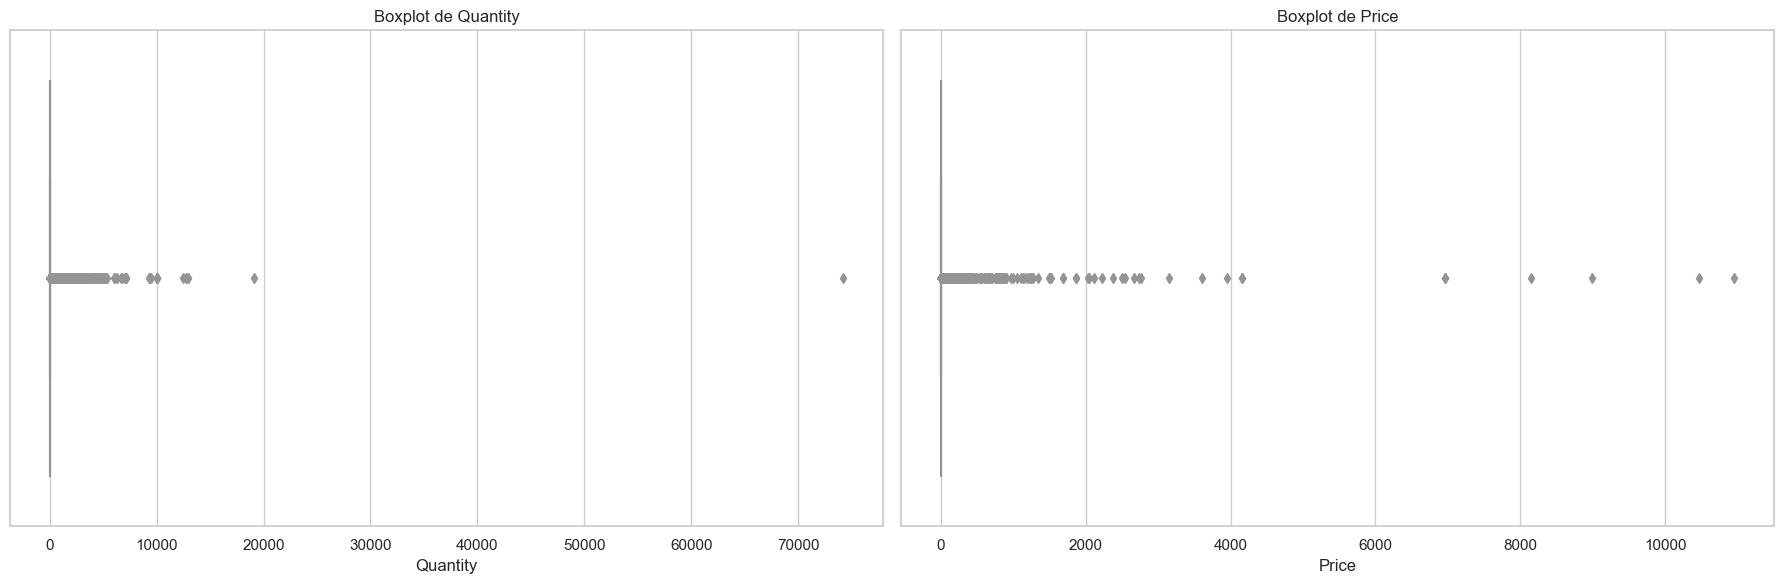

In [103]:
# Criar figura com subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))

# Boxplot para Quantity com outliers
sns.boxplot(ax=ax1, x=data['Quantity'], showfliers=True, palette="vlag")
ax1.set_title('Boxplot de Quantity')

# Boxplot para Price com outliers
sns.boxplot(ax=ax2, x=data['Price'], showfliers=True, palette="vlag")
ax2.set_title('Boxplot de Price')

plt.tight_layout()
plt.show()

           
                Boxplot "Quantity"
A maior parte dos valores de quantidade está concentrada próxima ao zero, o que significa que na maioria dos pedidos, muitos artigos são encomendados em baixas quantidades. Ainda assim, há uma quantidade significativa de valores fora do intervalo interquartil (IQR), indicando que existem transações que apresentam quantidades excepcionalmente altas.

                Boxplot "Price"
A maioria dos preços está concentrada na faixa de valores baixos, mas há preços significativamente maiores representados como outliers, o que significa que há artigos de preços bem mais elevados. (O que pode significar erro de registro ou unidades de medida inconsistentes)

Identificar esses outliers:

In [104]:
# Identificar outliers em 'Quantity'
outliers_idx_quantity = (data['Quantity'] < lower_bound) | (data['Quantity'] > upper_bound)

# Identificar outliers em 'Price'
outliers_idx_price = (data['Price'] < lower_bound_price) | (data['Price'] > upper_bound_price)

outliers = data[outliers_idx_price & outliers_idx_quantity]
print(f"Existem:{len(outliers)} outliers")
outliers


Existem:522 outliers


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
4405,489812,90035B,"PEARL & SHELL 42""NECKL. PINK",36,2.12.2009 13:00,8.49,17377.0,United Kingdom
18170,490933,84968E,S/16 VINTAGE BLACK CUTLERY,72,8.12.2009 13:46,10.95,14063.0,United Kingdom
18171,490933,84968D,S/16 VINTAGE RED CUTLERY,72,8.12.2009 13:46,10.95,14063.0,United Kingdom
22136,491143,37503,TEA TIME CAKE STAND IN GIFT BOX,36,9.12.2009 16:50,9.45,16029.0,United Kingdom
22198,491148,21843,RETRO SPOT CAKE STAND,48,10.12.2009 07:43,9.95,15061.0,United Kingdom
...,...,...,...,...,...,...,...,...
1022744,578358,21843,RED RETROSPOT CAKE STAND,72,24.11.2011 10:35,9.95,15482.0,United Kingdom
1024596,578626,22423,REGENCY CAKESTAND 3 TIER,32,24.11.2011 15:38,10.95,12709.0,Germany
1034391,579284,22752,SET 7 BABUSHKA NESTING BOXES,36,29.11.2011 10:52,7.65,15061.0,United Kingdom
1034398,579284,22423,REGENCY CAKESTAND 3 TIER,80,29.11.2011 10:52,10.95,15061.0,United Kingdom


Olhando para os outliers detatados da quantidade de artigos e do preço dos mesmos, estes só foram detetados como outliers pois os seus valores ou são maiores ou menores que a média dos restantes valores, ou seja, não são muito graves. Devido a isso, vai-se manter esses dados para análise.  

#### **Coversão de tipo de Dados:**

In [105]:
# Garantir que a coluna "InvoiceDate" se encontra no formato datetime e converter, se necessário.
data['InvoiceDate'] = pd.to_datetime(data['InvoiceDate'], format='%d.%m.%Y %H:%M')

## **Transformação dos Dados:**

A transformação dos dados é uma etapa de modelagem preditiva, que visa transformar os dados de maneira que estejam prontos para análise e sejam mais eficazes em responder às necessidades da análise. 

**Países ("Country"):**

In [106]:
# Verificar o nome dos diferentes países presentes 
countries = data['Country'].unique()

for country in countries:
    print(country)

total_countries = data['Country'].nunique()
print(f"Número total de países diferentes: {total_countries}")

United Kingdom
France
USA
Belgium
Australia
EIRE
Germany
Portugal
Denmark
Netherlands
Poland
Channel Islands
Spain
Cyprus
Greece
Norway
Austria
Sweden
United Arab Emirates
Finland
Italy
Switzerland
Japan
Unspecified
Nigeria
Malta
RSA
Singapore
Bahrain
Thailand
Israel
Lithuania
West Indies
Korea
Brazil
Canada
Iceland
Lebanon
Saudi Arabia
Czech Republic
European Community
Número total de países diferentes: 41


Como existem nomes países abreviados (Ex: "USA"), talvez seja melhor passar todos os países para maiúsculas para evitar erros durante a análise.

In [107]:
# Converter a coluna 'Country' para maiúsculas
data['Country'] = data['Country'].map(lambda x: x.upper())

data['Country']

0          UNITED KINGDOM
1          UNITED KINGDOM
2          UNITED KINGDOM
3          UNITED KINGDOM
4          UNITED KINGDOM
                ...      
1048570    UNITED KINGDOM
1048571    UNITED KINGDOM
1048572    UNITED KINGDOM
1048573    UNITED KINGDOM
1048574    UNITED KINGDOM
Name: Country, Length: 767369, dtype: object

**Artigos ("Description"):**

In [108]:
# Verificar o nome dos diferentes artigos presentes 
descriptions = data['Description'].unique()

for description in descriptions:
    print(description)

total_descriptions = data['Description'].nunique()
print(f"Número total de artigos diferente: {total_descriptions}")

15CM CHRISTMAS GLASS BALL 20 LIGHTS
PINK CHERRY LIGHTS
 WHITE CHERRY LIGHTS
RECORD FRAME 7" SINGLE SIZE 
STRAWBERRY CERAMIC TRINKET BOX
PINK DOUGHNUT TRINKET POT 
SAVE THE PLANET MUG
FANCY FONT HOME SWEET HOME DOORMAT
CAT BOWL 
DOG BOWL , CHASING BALL DESIGN
HEART MEASURING SPOONS LARGE
LUNCHBOX WITH CUTLERY FAIRY CAKES 
DOOR MAT BLACK FLOCK 
LOVE BUILDING BLOCK WORD
HOME BUILDING BLOCK WORD
ASSORTED COLOUR BIRD ORNAMENT
 PEACE WOODEN BLOCK LETTERS
CHRISTMAS CRAFT WHITE FAIRY 
HEART IVORY TRELLIS LARGE
HEART FILIGREE DOVE LARGE
FULL ENGLISH BREAKFAST PLATE
PIZZA PLATE IN BOX
BLACK DINER WALL CLOCK
SET OF 3 BLACK FLYING DUCKS
AREA PATROLLED METAL SIGN
PLEASE ONE PERSON  METAL SIGN
BATH BUILDING BLOCK WORD
CLASSIC WHITE FRAME
SMALL MARSHMALLOWS PINK BOWL
BISCUITS SMALL BOWL LIGHT BLUE
SCOTTIE DOG HOT WATER BOTTLE
CHRISTMAS CRAFT HEART DECORATIONS
CHRISTMAS CRAFT HEART STOCKING 
PARTY CONE CHRISTMAS DECORATION 
PEACE SMALL WOOD LETTERS
JOY LARGE WOOD LETTERS
CINAMMON & ORANGE WREATH
EUCAL

Como há artigos que contêm nomes com caracteres especiais, vai-se retirar os mesmos para simplicar, e também garantir que tudo se encontra convertido para maiusculas:

In [109]:
# Remover caracteres especiais 
data['Description'] = data['Description'].str.replace(r'[^a-zA-Z0-9 ]', '', regex=True)
data['Description']

0          15CM CHRISTMAS GLASS BALL 20 LIGHTS
1                           PINK CHERRY LIGHTS
2                          WHITE CHERRY LIGHTS
3                  RECORD FRAME 7 SINGLE SIZE 
4               STRAWBERRY CERAMIC TRINKET BOX
                          ...                 
1048570          DOORMAT KEEP CALM AND COME IN
1048571           MEMO BOARD RETROSPOT  DESIGN
1048572                  HEART OF WICKER SMALL
1048573                  VINTAGE BELLS GARLAND
1048574      PAPER LANTERN 9 POINT DELUXE STAR
Name: Description, Length: 767369, dtype: object

De modo a facilitar a análise, vai-se criar uma coluna "TotalValue" a qual corresponderá aos valores totais da compra da quantidade de artigos de acordo com o preço unitário: *TotalValue = Price * Quantity*.

In [110]:
# Criar uma coluna com o valor total da compra "TotalValue" (preço * quantidade)
data['TotalValue'] = data['Price'] * data['Quantity']
data.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,TotalValue
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,UNITED KINGDOM,83.4
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,UNITED KINGDOM,81.0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,UNITED KINGDOM,81.0
3,489434,22041,RECORD FRAME 7 SINGLE SIZE,48,2009-12-01 07:45:00,2.10,13085.0,UNITED KINGDOM,100.8
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,UNITED KINGDOM,30.0


Olhando para todos os outputs do dataset que têm aparecido até agora, e com base no tipo de valores das tabelas verificado incialmente, constata-se que a coluna do "Customer ID" se encontra do tipo float, quando todos os número são inteiros. Vai-se converter essa coluna para o tipo "int".

In [111]:
# Definir a coluna "Customer ID" para int

data['Customer ID'] = data['Customer ID'].astype(int)
data.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,TotalValue
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085,UNITED KINGDOM,83.4
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,UNITED KINGDOM,81.0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,UNITED KINGDOM,81.0
3,489434,22041,RECORD FRAME 7 SINGLE SIZE,48,2009-12-01 07:45:00,2.10,13085,UNITED KINGDOM,100.8
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085,UNITED KINGDOM,30.0


## **Estudos com dados Agrupados:**

Os estudos com dados agrupados referem-se à prática de organizar e analisar dados em grupos de modo a identificar padrões, tendências e insights. Esta abordagem é comumente utilizada em várias áreas, incluindo estatísticas, ciência dos dados, análise de negócios... Ao invés de examinar cada registro individualmente, os dados são agrupados com base em categorias ou intervalos específicos.

É dentro do estudo com dados agrupados que serão realizadas as análises descritas inicialmente.

Vai-se primeiro retirar informação necessária que pode ser crucial antes de começar, como o número total de descrições\Artigos diferentes e do número total de clientes presentes no dataset:

In [112]:
# Quantidade de descrições diferentes
total_descriptions = data['Description'].nunique()

print(f"Número total de artigos diferentes: {total_descriptions}")

# Quantidade de clientes
total_clients = data['Customer ID'].nunique()

print(f"Número total de clientes: {total_clients}")
print(f"Número total de países diferentes: {total_countries}")

Número total de artigos diferentes: 5230
Número total de clientes: 5860
Número total de países diferentes: 41


Da análise das células anteriores tinha-se verificado que existiam 5281 artigos diferentes, mas agora só se encontram 5230 artigos, ou seja, antes havia artigos com o mesmo nome mas de formas diferentes ao fazer a limpeza dos caracteres especiais pode-se verificar de forma mais credível quantos artigos diferente existem no dataset.

Passando agora às análises.

## 1. **Análise do tipo Transações realizadas:**

A Análise do Tipo de Transações Realizadas é uma abordagem que ajuda a compreender os padrões de comportamento dos clientes em relação às compras num e-commerce ou numa plataforma de vendas online. Foc-se em entender as características das transações realizadas, como o número de itens comprados, o valor total das compras, a frequência de compra, e a forma como as transações ocorrem. Esta análise oferece insights profundos sobre o comportamento do consumidor e a eficiência das estratégias de vendas.

Ao analisar os tipos de transações realizadas, pode-se vir a entender melhor se os clientes estão compram com frequência, se tendem a comprar em grandes quantidades ou pequenas, ou se há um padrão de compra repetida.
Ajuda a identificar clientes que realizam compras únicas versus clientes que fazem compras recorrentes, permitindo assim segmentar o público para estratégias de marketing mais direcionadas.

Para esta análise primeiro ir-se-á agrupar os dados 'Invoice', 'Customer ID', 'InvoiceDate', 'StockCode', 'Quantity', 'TotalValue' e 'Country' de modo a obter as informações sobre as várias transações diferentes que ocorreram. Através desse agrupado de dados vai-se criar um novo dataset *"total_shops"*. Em seguida, vai-se obter o valor médio de compras feitas (em termos monetários) e com base nisso vamos dividir o tamanho das transações em 3 categorias. Depois ir-se-á repetir esse último processo mas para as quantidades totais de artigos presentes em cada transação. No fim analisar-se-á os resultados obtidos.

In [113]:
# Total de Compras
total_shops= data.groupby(['Invoice', 'Customer ID', 'InvoiceDate']).agg({
    'StockCode': lambda x: len(x.unique()), 
    'Quantity': 'sum',
    'TotalValue': 'sum',                        
    'Country': 'first'                        
}).reset_index()

total_shops = pd.DataFrame(total_shops)

total_shops

,Invoice,Customer ID,InvoiceDate,StockCode,Quantity,TotalValue,Country
0,489434,13085,2009-12-01 07:45:00,8,166,505.30,UNITED KINGDOM
1,489435,13085,2009-12-01 07:46:00,4,60,145.80,UNITED KINGDOM
2,489436,13078,2009-12-01 09:06:00,19,193,630.33,UNITED KINGDOM
3,489437,15362,2009-12-01 09:08:00,23,145,310.75,UNITED KINGDOM
4,489438,18102,2009-12-01 09:24:00,17,826,2286.24,UNITED KINGDOM
...,...,...,...,...,...,...,...
36516,580482,16033,2011-12-04 12:44:00,73,206,421.87,UNITED KINGDOM
36517,580490,15773,2011-12-04 12:48:00,10,311,635.68,UNITED KINGDOM
36518,580500,17131,2011-12-04 12:52:00,52,418,1067.33,UNITED KINGDOM
36519,580501,14546,2011-12-04 13:00:00,70,231,495.83,UNITED KINGDOM


Neste novo dataset as colunas: Invoice, Customer ID, InvoiceDate, TotalValue e Country mantêm o mesmo significado; 
A coluna **'StockCode'** é uma nova coluna que soma a quantidade de artigos *diferentes* presentes em cada transação e a coluna **Quantity** é a soma *total* de artigos de cada transação.

Para não fazer confusão, vai-se alterar os nomes das mesmas:
- StockCode para "Articles";
- Quantity para "TotalArtQuant".

In [114]:
total_shops.rename(columns={'StockCode': 'Articles', 'Quantity': 'TotalArtQuant'}, inplace=True)

total_shops.to_csv('total_shops.csv', index=True)

total_shops

,Invoice,Customer ID,InvoiceDate,Articles,TotalArtQuant,TotalValue,Country
0,489434,13085,2009-12-01 07:45:00,8,166,505.30,UNITED KINGDOM
1,489435,13085,2009-12-01 07:46:00,4,60,145.80,UNITED KINGDOM
2,489436,13078,2009-12-01 09:06:00,19,193,630.33,UNITED KINGDOM
3,489437,15362,2009-12-01 09:08:00,23,145,310.75,UNITED KINGDOM
4,489438,18102,2009-12-01 09:24:00,17,826,2286.24,UNITED KINGDOM
...,...,...,...,...,...,...,...
36516,580482,16033,2011-12-04 12:44:00,73,206,421.87,UNITED KINGDOM
36517,580490,15773,2011-12-04 12:48:00,10,311,635.68,UNITED KINGDOM
36518,580500,17131,2011-12-04 12:52:00,52,418,1067.33,UNITED KINGDOM
36519,580501,14546,2011-12-04 13:00:00,70,231,495.83,UNITED KINGDOM


Na totalidade do dataset ocorreram 36521 transações, sendo que a primeira ocorreu a 1 de dezembro de 2009 às 7:45 e a última ocorreu no dia 4 de dezembro de 2011 às 13:15. (Tem em conta as compras realizadas ao longo de 733 dias).

In [115]:
total_shops.describe()

,Customer ID,InvoiceDate,Articles,TotalArtQuant,TotalValue
count,36521.000000,36521,36521.00000,36521.000000,36521.000000
mean,15298.421319,2010-12-21 23:57:59.760137984,20.72906,281.556830,464.305494
min,12346.000000,2009-12-01 07:45:00,1.00000,1.000000,0.380000
25%,13804.000000,2010-06-27 13:00:00,6.00000,72.000000,157.500000
50%,15219.000000,2010-11-29 09:38:00,15.00000,151.000000,302.860000
75%,16791.000000,2011-07-04 15:13:00,27.00000,287.000000,477.140000
max,18287.000000,2011-12-04 13:15:00,541.00000,87167.000000,77183.600000
std,1720.361478,NaN,22.16743,1163.912544,1041.522546


Pontos Chave a reter:
- A quantidade média de artigos diferentes comprados por transação é de 20,73 artigos (21 artigos por compra), com um total máximo de 541 artigos diferentes numa única transação, mas o desvio padrão é de 22,17 o que indica uma variação significativa na quantidade de artigos comprados por transação.
- A média da quantidade total de artigos por transação são 281,56 artigos (282 artigos por compra), sendo que a compra com mais artigos contém 87167 artigos.
- A transação com maior quantidade total de artigos teve 87167 artigos.
O valor médio das compras por transação é de 464,30£, com um desvio padrão de 1041,52, o que mostra uma grande disparidade nos valores das transações.
- A transação de maior valor totalizou 77183,60£, enquanto a menor foi de apenas 0,38£.

In [116]:
# Média dos valores totais de compra.
media_total_value = total_shops['TotalValue'].mean()

# Arredondar para 2 casas decimais
media_total_value = round(media_total_value, 2)

print(f'A média dos valores totais de compra é: {media_total_value}£')


A média dos valores totais de compra é: 464.31£


Vai agora ser criada uma nova coluna "TransactionSize" dentro do agrupamento de dados "total_shops" a qual vai ser responsável categorizar os valores totais por transação.

Os rótulos definidos para as categorias vai ter haver com o valor da média do valor total de compras realizadas (464,31£): até 90% do valor da média **Pequena**, entre 90% do valor da média e 110% **Normal**, acima de 110% do valor da média **Grande**. 

In [117]:
# Definir os limites e rótulos para categorizar as transações com base na média
limite_inferior = media_total_value * 0.9
limite_superior = media_total_value * 1.1

bins = [0, limite_inferior, limite_superior, float('inf')]
labels = ['Pequena', 'Normal', 'Grande']

# Criar a nova coluna 'TransactionSize'
total_shops['TransactionSize'] = pd.cut(total_shops['TotalValue'], bins=bins, labels=labels)

total_shops


,Invoice,Customer ID,InvoiceDate,Articles,TotalArtQuant,TotalValue,Country,TransactionSize
0,489434,13085,2009-12-01 07:45:00,8,166,505.30,UNITED KINGDOM,Normal
1,489435,13085,2009-12-01 07:46:00,4,60,145.80,UNITED KINGDOM,Pequena
2,489436,13078,2009-12-01 09:06:00,19,193,630.33,UNITED KINGDOM,Grande
3,489437,15362,2009-12-01 09:08:00,23,145,310.75,UNITED KINGDOM,Pequena
4,489438,18102,2009-12-01 09:24:00,17,826,2286.24,UNITED KINGDOM,Grande
...,...,...,...,...,...,...,...,...
36516,580482,16033,2011-12-04 12:44:00,73,206,421.87,UNITED KINGDOM,Normal
36517,580490,15773,2011-12-04 12:48:00,10,311,635.68,UNITED KINGDOM,Grande
36518,580500,17131,2011-12-04 12:52:00,52,418,1067.33,UNITED KINGDOM,Grande
36519,580501,14546,2011-12-04 13:00:00,70,231,495.83,UNITED KINGDOM,Normal


Para vizualizar melhor os resultados de categorizar as compras, recorre-se a gráfico circular:

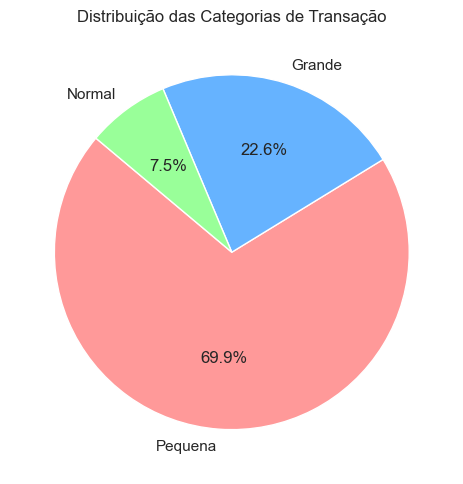

In [118]:
# Contar as categorias
transaction_size_counts = total_shops['TransactionSize'].value_counts()

# Criar gráfico circular
plt.figure(figsize=(5, 5))
transaction_size_counts.plot.pie(
    autopct='%1.1f%%', 
    startangle=140, 
    colors=['#ff9999', '#66b3ff', '#99ff99'],
    labels=transaction_size_counts.index
)
plt.title('Distribuição das Categorias de Transação')
plt.ylabel('') 
plt.tight_layout()
plt.show()

Este gráfico demonstra uma grande predominância de transações pequenas (69.9%), o que indica que o volume maior de compras é feito em transações de menor valor, o que pode refletir um padrão de compra típico em que os clientes preferem gastar menos em cada transação, possivelmente adquirindo poucos itens ou produtos de menor preço.
As transações grandes (22.6%), quase um quarto das transações, mostra que ainda existe um volume significativo de compras de alto valor, talvez refletindo compras em maior quantidade ou produtos mais caros.
As transações médias/normais (7.5%), são um valor mais baixo, o que mostra que pode há uma lacuna entre os valores baixos e altos, sugerindo que as transações tendem a concentrar-se maioritariamente nos extremos (Pequena ou Grande).

Passando agora à quantidade total de artigos por compra:

In [119]:
# Média das quantidades totais de artigos por compra.
quantity_total = total_shops['TotalArtQuant'].mean()

# Arredondar para não ter casas decimais.
quantity_total = round(quantity_total, 0)

print(f'A média das quantidades totais de artigos por compra é: {quantity_total} artigos')

A média das quantidades totais de artigos por compra é: 282.0 artigos


Vai agora ser criada uma nova coluna "ShopSize" dentro do agrupamento de dados "total_shops" a qual vai ser responsável categorizar as compras, com base na quantidade total de artigos que compram.

Os rótulos definidos para as categorias vai ter haver com o valor da média das quantidades totais de artigos por compra (282 artigos): até 90% do valor da média **Pequena**, entre 90% do valor da média e 110% **Normal**, acima de 110% do valor da média **Grande**. 

In [120]:
# Definir os limites e rótulos para categorizar as transações com base na média
limite_inferior = quantity_total * 0.9
limite_superior = quantity_total * 1.1

bins = [0, limite_inferior, limite_superior, float('inf')]
labels = ['Pequena', 'Normal', 'Grande']

# Criar a nova coluna 'TransactionSize'
total_shops['ShopSize'] = pd.cut(total_shops['TotalArtQuant'], bins=bins, labels=labels)

total_shops

,Invoice,Customer ID,InvoiceDate,Articles,TotalArtQuant,TotalValue,Country,TransactionSize,ShopSize
0,489434,13085,2009-12-01 07:45:00,8,166,505.30,UNITED KINGDOM,Normal,Pequena
1,489435,13085,2009-12-01 07:46:00,4,60,145.80,UNITED KINGDOM,Pequena,Pequena
2,489436,13078,2009-12-01 09:06:00,19,193,630.33,UNITED KINGDOM,Grande,Pequena
3,489437,15362,2009-12-01 09:08:00,23,145,310.75,UNITED KINGDOM,Pequena,Pequena
4,489438,18102,2009-12-01 09:24:00,17,826,2286.24,UNITED KINGDOM,Grande,Grande
...,...,...,...,...,...,...,...,...,...
36516,580482,16033,2011-12-04 12:44:00,73,206,421.87,UNITED KINGDOM,Normal,Pequena
36517,580490,15773,2011-12-04 12:48:00,10,311,635.68,UNITED KINGDOM,Grande,Grande
36518,580500,17131,2011-12-04 12:52:00,52,418,1067.33,UNITED KINGDOM,Grande,Grande
36519,580501,14546,2011-12-04 13:00:00,70,231,495.83,UNITED KINGDOM,Normal,Pequena


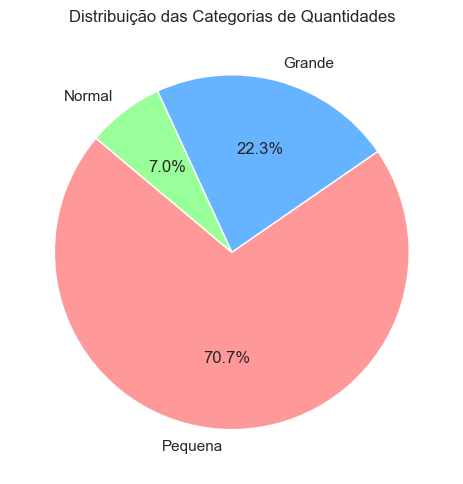

In [121]:
# Contar as categorias
size_counts = total_shops['ShopSize'].value_counts()

# Criar gráfico circular
plt.figure(figsize=(5, 5))
size_counts.plot.pie(
    autopct='%1.1f%%', 
    startangle=140, 
    colors=['#ff9999', '#66b3ff', '#99ff99'],
    labels=size_counts.index
)
plt.title('Distribuição das Categorias de Quantidades')
plt.ylabel('') 
plt.tight_layout()
plt.show()

Com base neste gráfico, pode-se concluir que a grande maioria das compras (aproximadamente 71%) inclui uma quantidade pequena de artigos, ou seja, a maior parte das compras tende a ser composta por um número reduzido de itens, o que sugere que o padrão mais comum de compra é de pequenas quantidades de artigos. 
Aproximadamente 22% das compras incluem uma quantidade grande de artigos. Embora esta percentagem seja significativa, ainda assim, é uma fatia menor em comparação com as compras "Pequenas", o que indica que há uma parte considerável dos clientes que compram em maiores quantidade, mas não são a maior parte deles.
Apenas cerca de 7% das compras estão associadas a uma quantidade normal de artigos, o que sugere que este é um intervalo menos frequente, e as compras tendem a ser nem muito pequenas nem muito grandes.

Comparando os dois gráficos circulares, as percentagens até são muito semelhantes. Analisando categoria a categoria:

Pequena:
- Quantidade de artigos pequena (70,7%): A maior parte das compras tem uma quantidade reduzida de itens.
- Valor pequeno (69,9%): A maioria das compras também tende a ter um valor baixo.
- A maioria das transações envolve poucas compras com um valor baixo, indicando que os clientes tendem a comprar menos itens, mas com um gasto reduzido.

Grande:
- Quantidade grande de artigos (22,3%): Menos comum do que a quantidade pequena, mas ainda representando uma parte significativa das transações.
- Valor grande (22,6%): Aproximadamente a mesma proporção de compras com valores grandes, o que sugere que, ao comprar em maior quantidade, o cliente tende a gastar também mais.
- As compras com grandes quantidades de artigos também têm valores grandes, sugerindo que os clientes que compram mais itens gastam mais.

Normal:
- Quantidade normal de artigos (7,0%): Esta categoria é a menos frequente, com apenas 7% das compras se enquadrando nesse intervalo.
- Valor normal (7,5%): Similarmente, as compras com um valor total "normal" são igualmente raras.
- As compras que têm uma quantidade e um valor "normal" representam uma pequena parte do total de transações. Parece ser um intervalo intermediário que é menos comum.

In [122]:
# Contagem de transações por cliente dentro de cada combinação de TransactionSize e ShopSize
contagens_repeticoes = total_shops.groupby(['TransactionSize', 'ShopSize', 'Customer ID']).size().reset_index(name='Repeticoes')

# Contagem das repetições para cada combinação de TransactionSize e ShopSize
contagens_combinadas = contagens_repeticoes.groupby(['TransactionSize', 'ShopSize'])['Repeticoes'].sum().reset_index(name='Total')

# Criação de uma tabela dinâmica (pivot table) para facilitar o heatmap
pivot_table = contagens_combinadas.pivot(index='TransactionSize', columns='ShopSize', values='Total')
pivot_table



C:\Users\andre\AppData\Local\Temp\ipykernel_26560\4070690399.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  contagens_repeticoes = total_shops.groupby(['TransactionSize', 'ShopSize', 'Customer ID']).size().reset_index(name='Repeticoes')
C:\Users\andre\AppData\Local\Temp\ipykernel_26560\4070690399.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  contagens_combinadas = contagens_repeticoes.groupby(['TransactionSize', 'ShopSize'])['Repeticoes'].sum().reset_index(name='Total')


ShopSize,Pequena,Normal,Grande
TransactionSize,,,
Pequena,22983,1196,1336
Normal,1470,526,760
Grande,1379,839,6032


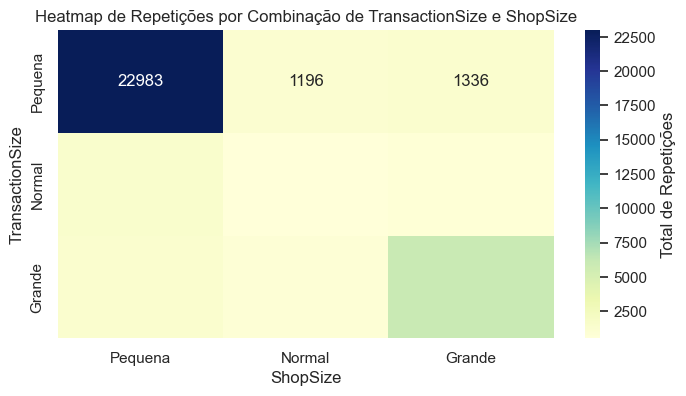

In [123]:
# Plotando o heatmap
plt.figure(figsize=(8, 4))  # Tamanho da figura
sns.heatmap(pivot_table, annot=True, fmt='d', cmap="YlGnBu", cbar_kws={'label': 'Total de Repetições'})

# Ajustando título e rótulos
plt.title('Heatmap de Repetições por Combinação de TransactionSize e ShopSize')
plt.xlabel('ShopSize')
plt.ylabel('TransactionSize')

# Exibindo o gráfico
plt.show()

Comparando o tamanho do valor das compras com a quantidade de unidades:

- A maioria das transações envolve pequenas quantidades de artigos comprados e um valor total baixo.
Este comportamento pode ser reflexo de clientes que compram itens esporádicos ou de baixo custo, havendo um foco maior em consumidores individuais, invés de atacadistas ou grandes compradores.
Há uma pouca frequência de compras de grande valor ou grandes quantidades, sendo rara a presença de ambas, mas mesmo assim encontra-se acima das 5000 transações.

Compras de alto valor são menos comuns, mesmo em transações de grande volume, o que pode significar que o público-alvo prefere compras mais frequentes e de menor escala.
De modo a corrigir isto pode-se criar "incentivos" ou produtos adequados para promover compras de alto valor ou grandes quantidades.
Os produtos com preços acessíveis podem favorecer compras as de valor mais baixo e em menor quantidade.

Concluindo, com esta análise demonstra-se que o comportamento dos clientes é maioritariamente orientado a compras de pequeno porte, tanto em valor quanto em quantidade, o que pode ser positivo em um modelo de negócios virado para volume de transações pequenas, pois eleva a frequência com que as pessoas podem realizar compras, aumentando assim o lucro a longo prazo. Por outro lado há espaço para poder incentivar compras maiores (em valor e quantidade) de modo a aumentar ainda mais os lucros. Para tal devem ser promovidas estratégias de marketing que estimulem compras regulares e de maior porte.

## 2. **Análise de vendas por país:**


A Análise de Vendas por País é um processo de segmentação geográfica que avalia o desempenho das vendas de produtos diferentes países. Ao realizar essa análise, é possível identificar quais países são mais lucrativos, onde as vendas estão crescendo ou diminuindo, e quais mercados têm potencial para expansão ou ajuste estratégico.

Para esta análise irão ser examinaados indicadores como:
- Receita Gerada: Total do valor monetário das vendas por país.
- Produtos Populares: Itens mais vendidos em cada mercado.
- Volume de Vendas: Quantidade de produtos vendidos em cada país.

No final desta análise pretende-se que os resultados guiem a empresa na adaptação às dinâmicas específicas de cada mercado, otimizando o desempenho global.

### 1. Receita Gerada

(Soma dos valores totais de compras realizadas em cada país).

In [124]:
# Total de vendas por país
sales_by_country = total_shops.groupby('Country')['TotalValue'].sum().sort_values(ascending=False)
sales_by_country

Country
UNITED KINGDOM          1.400996e+07
EIRE                    6.102686e+05
NETHERLANDS             5.423101e+05
GERMANY                 4.177984e+05
FRANCE                  3.439847e+05
AUSTRALIA               1.692835e+05
SPAIN                   1.080163e+05
SWITZERLAND             1.000619e+05
SWEDEN                  9.127782e+04
DENMARK                 6.841179e+04
BELGIUM                 6.428041e+04
PORTUGAL                5.418352e+04
NORWAY                  5.353680e+04
CHANNEL ISLANDS         4.442493e+04
JAPAN                   4.302391e+04
ITALY                   3.190772e+04
FINLAND                 2.992554e+04
SINGAPORE               2.531706e+04
CYPRUS                  2.484995e+04
AUSTRIA                 2.292981e+04
GREECE                  1.841520e+04
POLAND                  1.065429e+04
ISRAEL                  1.041524e+04
UNITED ARAB EMIRATES    9.202690e+03
UNSPECIFIED             8.607350e+03
MALTA                   8.099090e+03
USA                     7.7515

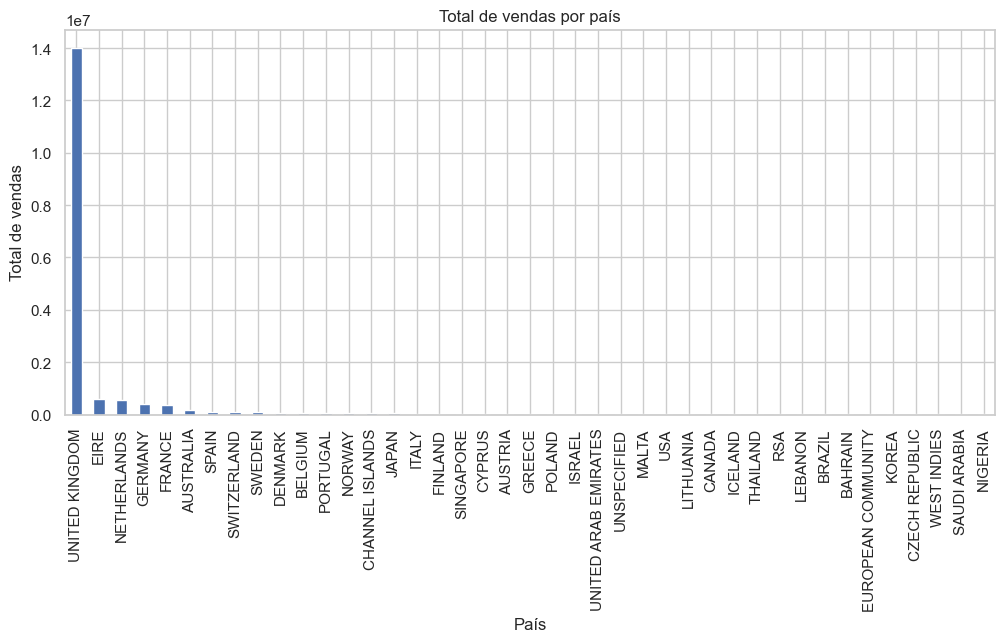

In [125]:
#Gráfico de barras para vendas por país
plt.figure(figsize=(12, 5))
sales_by_country.plot(kind='bar', title='Total de vendas por país')
plt.ylabel('Total de vendas')
plt.xlabel('País')
plt.show()

País com a maior e a menor venda

In [126]:
country_max_sales = sales_by_country.idxmax()  # País com a maior venda
country_min_sales = sales_by_country.idxmin()  # País com a menor venda
print("País com a maior venda:", country_max_sales)
print("País com a menor venda:", country_min_sales)

País com a maior venda: UNITED KINGDOM
País com a menor venda: NIGERIA


Com base no gráfico de barras reflete-se que o Reino Unido é, de longe, o país com o maior volume de vendas, com um valor total de mais de 14 milhões. A sua diferença para com os restantes países é extremamente significativa, o que destaca a sua importãncia no mercado principal.

Olhando para os Países que se encontram aseguir à Bélgica esses nem são precetíveis no gráfico apresentando valores muito próximos de 0.
A Nigéria aparece como o país com o menor volume de vendas no conjunto de dados. O valor é tão baixo que mal é perceptível no gráfico, o que indica que a empresa tem pouca ou nenhuma penetração neste mercado, possivelmente devido a fatores como logística, demanda limitada ou ausência de estratégias de marketing direcionadas.

- *Concentração de Vendas:*
O gráfico revela uma grande concentração de vendas em poucos países, com o Reino Unido dominando e alguns países da Europa, como o EIRE, a Alemanha, a França e os Países Baixos, apresentando valores relevantes, embora muito menores. Muitos outros países têm contribuições marginais, o que reforça o facto de a empresa depender fortemente de apenas poucos mercados.

A dependência no Reino Unido é um risco potencial para o negócio, caso surjam mudanças econômicas ou políticas que afetem este mercado. Investimentos em mercados com vendas baixas, mas com potencial de crescimento (como a Alemanha ou a França ou a Espanha), podem ajudar a reduzir essa dependência e aumentar a diversificação.
A Nigéria, entre outros países com vendas baixas, que se encontrem especialmente fora da Europa pode não justificar grandes investimentos imediatos, mas pode vir a ser analisada no longo prazo para verificar oportunidades em regiões com baixa penetração.

Percentagens do Top 5 de países:

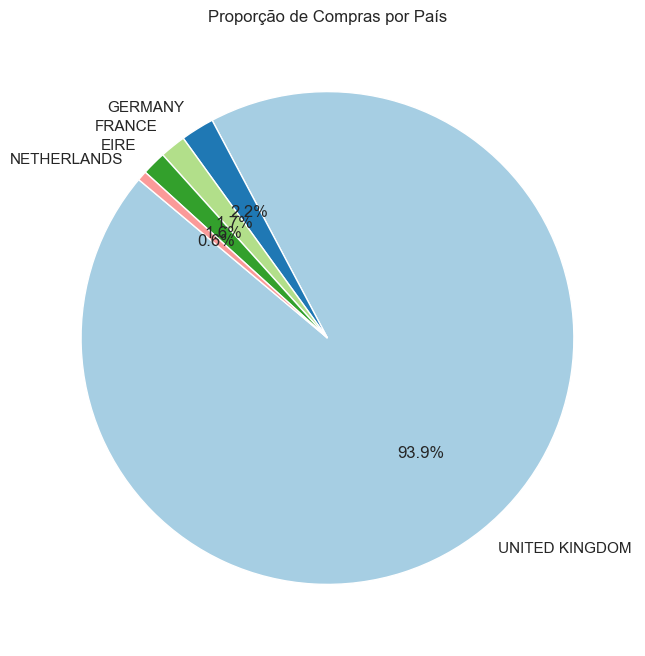

In [127]:
# Contagem de compras por país
country_counts = total_shops['Country'].value_counts()
country_counts = country_counts.head(5)
# Criação do gráfico circular
plt.figure(figsize=(10, 8))
country_counts.plot.pie(autopct='%1.1f%%', startangle=140, colors=plt.cm.Paired.colors)
plt.title('Proporção de Compras por País')
plt.ylabel('')
plt.show()

(Aqui só se selecionou o Top 5 de países, pois como se verificou nos outputs anteriores, o Reino Unido domina esmagadoramente as vendas com mais de 14 milhões em valores de vendas. Os outros países apresentam valores muito menores, com o segundo país (EIRE) representando apenas cerca de 1,6% das vendas totais, o que acaba a tornar a análise de todos os países irrelevante para um gráfico circular, já que os valores menores teriam pouca representatividade. Incluir todos os países resultaria em muitas fatias pequenas, dificultando a interpretação dos dados.)

Como já explicado anteriormente o Reino Unido domina as vendas, representando 93,3% das transações, o que para este tipo de "empresa" confirma que é o mercado mais relevantes e prioritário, se fosse para desenvolver estratégias de retenção e expansão.

Países como EIRE, Alemanha, França e Países Baixos possuem uma representatividade muito pequena, variando de 2,2% a 0,7% das transações, tal acontece com os restantes países que não foram tidos em conta para este gráfico. Apesar da baixa participação, estes países poderiam vir a ser explorados como mercados secundários, onde ajustes em estratégias de marketing e logística podem aumentar a participação.

Por fim, confirma-se que existe uma grande concentração de vendas em apenas um país, indicando que este tipo de "negócio" é fortemente dependente de um único mercado. A diversificação para outros países pode ser uma oportunidade de reduzir riscos. Países como EIRE (2,2%) podem ser bons alvos para campanhas localizadas, dado que já possuem uma base mínima de operações, e se encontram próximos da "loja base". Por outro lado, países como os que não se encontram neste gráfico, poderiam vir a precisar de uma análise maior de modo a justificar os investimentos.

Média e mediana de vendas por país:

In [128]:
mean_by_country = total_shops.groupby('Country')['TotalValue'].mean().sort_values(ascending=False)
median_by_country = total_shops.groupby('Country')['TotalValue'].median().sort_values(ascending=False)
mean_df = mean_by_country.to_frame(name='Mean')
median_df = median_by_country.to_frame(name='Median')
sum_df = mean_df.join([median_df])
sum_df

,Mean,Median
Country,,
NETHERLANDS,2410.266978,612.000
SINGAPORE,2301.550909,2053.070
AUSTRALIA,1781.931158,384.680
LEBANON,1693.880000,1693.880
DENMARK,1628.852143,703.740
THAILAND,1535.270000,1535.270
ISRAEL,1487.891429,1248.420
NORWAY,1274.685714,728.535
JAPAN,1265.409118,274.860


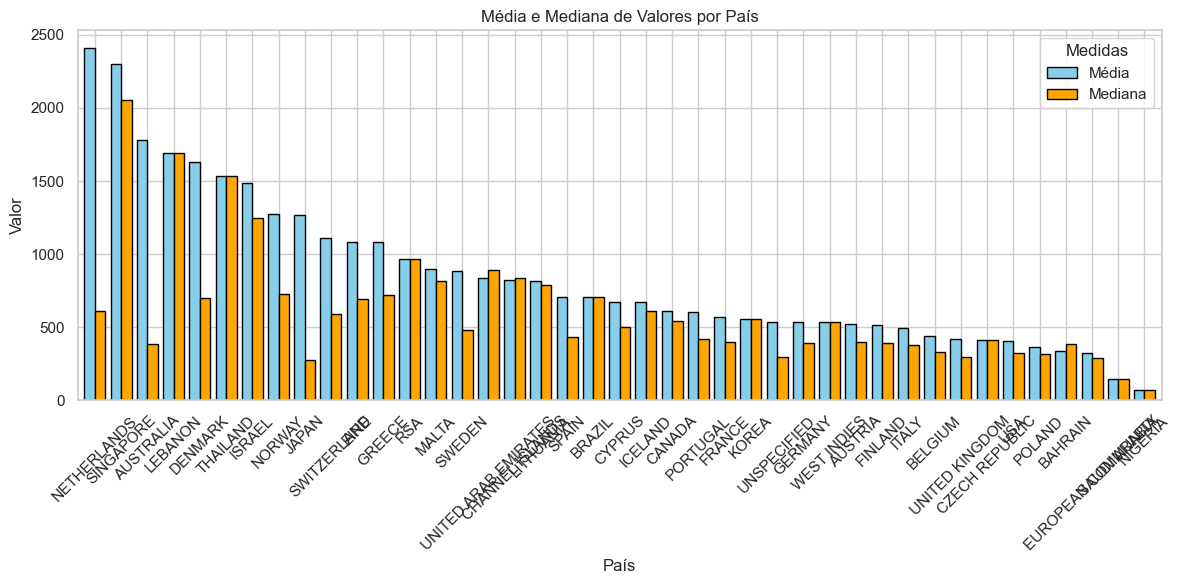

In [129]:
# Criação do gráfico de barras para média e mediana por país
sum_df.plot(kind='bar', figsize=(12, 6), color=['skyblue', 'orange'], edgecolor='black', width=0.8)

plt.title('Média e Mediana de Valores por País')
plt.xlabel('País')
plt.ylabel('Valor')
plt.xticks(rotation=45)  # Rotaciona os rótulos dos países para facilitar a leitura
plt.legend(['Média', 'Mediana'], title='Medidas')
plt.tight_layout()
plt.show()

    Países com Valores Singulares de Compra Mais Altos (Média e Mediana):
A Holanda (Netherlands) apresenta a maior média (2410.27£), mas uma mediana relativamente baixa (612.00£), destacando-se como o país com os valores de compra mais altos. Outros países com médias altas incluem Singapura (2301.55£) e o Lebanon (1693.88£), os quais também apresentamos seus valores de mediana muito semelhantes ao da média apesar de suas medianas também serem significativamente menores em comparação com a média.

    Discrepância entre Média e Mediana:
Países como o Japão e a Austrália mostram uma grande diferença entre a média e a mediana, sugerindo a ocorrência de compras esporádicas de alto valor que elevam a média, mas que não representam o comportamento típico do consumidor (mais próximo da mediana).
Por outro lado, países como o Lebanon (1693.880£ média e	1693.880£ mediana) e a Tailândia (1535.270£ média e 1535.270£ mediana) exibem valores exatamente iguais entre média e mediana, indicando compras mais consistentes e menos dispersas.

    Países com Menores Valores Singulares de Compra (Média e Mediana):
Os países com as menores médias e medianas são Nigéria (70.20£) e Arábia Saudita (145.92£). Esses valores podem refletir mercados com menor volume de compras ou valores menores por transação, possivelmente devido a diferenças econômicas ou culturais.

    Comparação com o Reino Unido:
O Reino Unido aparece numa posição mais baixa na tabela, com uma média de 422.74£ e uma mediana de 298.32£, bastante inferiores aos líderes como Holanda e Singapura, o que sugere que o alto volume de transações no Reino Unido é o que contribui para os valores totais expressivos, enquanto o valor unitário médio de cada compra é relativamente baixo.

O gráfico reflete que, em muitos casos, a média supera a mediana, indicando a presença de valores extremos que aumentam a média. A dispersão entre média e mediana em países intermediários sugere diferenças nos hábitos de consumo ou na distribuição das compras. Esses contrastes destacam fatores econômicos, culturais e características específicas do mercado, influenciando os padrões de compra em diferentes países.

Variância e Desvio padrão de valores totais de compras por país:

In [130]:
# Calcular a variância e o desvio padrão por país
variance_by_country = total_shops.groupby('Country')['TotalValue'].var().sort_values(ascending=False)
std_by_country = total_shops.groupby('Country')['TotalValue'].std().sort_values(ascending=False)
variance_df = variance_by_country.to_frame(name='Variance')
std_df = std_by_country.to_frame(name='Standard Deviation')
summary_df = variance_df.join([std_df])
summary_df

,Variance,Standard Deviation
Country,,
AUSTRALIA,2.067677e+07,4547.171630
NETHERLANDS,1.543075e+07,3928.198926
DENMARK,8.340253e+06,2887.949646
EIRE,6.110401e+06,2471.922518
SINGAPORE,3.170323e+06,1780.540143
SWITZERLAND,3.033742e+06,1741.764125
JAPAN,2.784559e+06,1668.699679
ISRAEL,2.715002e+06,1647.726186
NORWAY,2.599593e+06,1612.325410


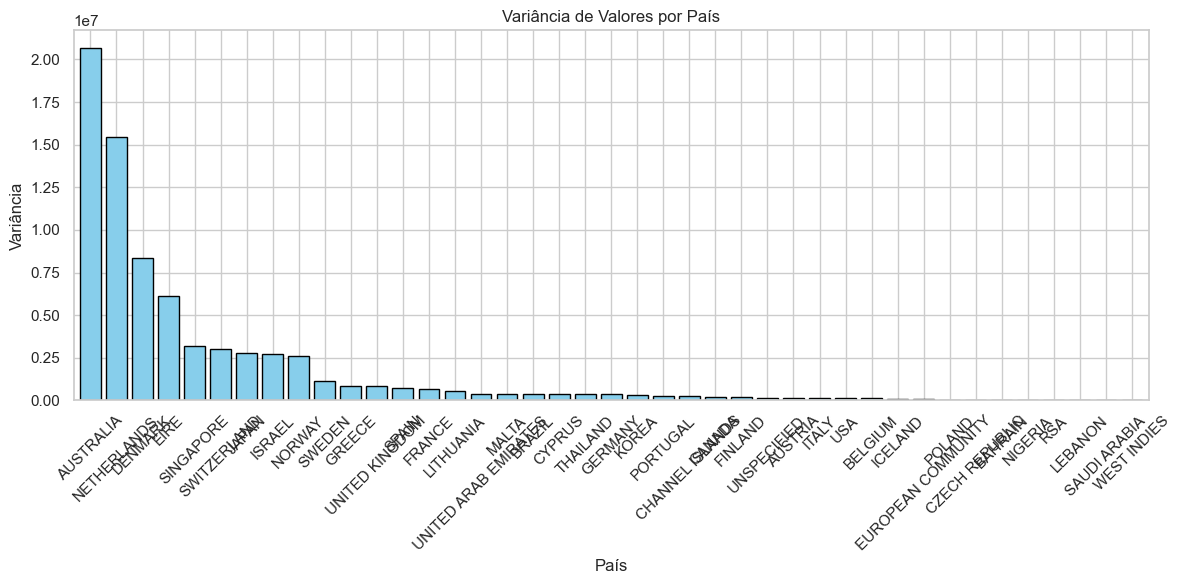

In [131]:
# Criação do gráfico de barras apenas para a Variância por país
summary_df['Variance'].plot(kind='bar', figsize=(12, 6), color='skyblue', edgecolor='black', width=0.8)

plt.title('Variância de Valores por País')
plt.xlabel('País')
plt.ylabel('Variância')
plt.xticks(rotation=45)  # Rotaciona os rótulos dos países para facilitar a leitura
plt.tight_layout()
plt.show()


Países com Valores de Variância Mais Elevados:
A Austrália apresenta a maior variância (20676770), indicando que os valores de compra neste país apresentam grandes flutuações, com transações variando de valores muito baixos a valores extremamente altos. Outros países com variâncias elevadas incluem a Holanda (15430750), Dinamarca (8340253) e a Irlanda (EIRE).
O Japão (2784559) e Israel (2715002) também apresentam valores de variância altos. Esses países apresentam consumidores heterogêneos, com segmentos que realizam compras de valores elevados enquanto outros fazem compras menores, consistente com as diferenças entre média e mediana observadas nesses mercados.

Países com valores baixos de Variância:
Países como a Nigéria (3591) e RSA (2512) apresentam variâncias extremamente baixas, indicando que as compras nesses países são mais uniformes e possuem menor dispersão, o que reflete padrões de consumo mais homogêneos, em que a diferença entre média e mediana é menor.

Países com Valores Não Disponíveis (NaN):
Os valores de variância e desvio padrão para o Líbano, Arábia Saudita e West Indies não estão disponíveis (NaN), pois os valores de média e mediana são exatamente iguais, o que pode indicar que os dados de compras para esses países são insuficientes para calcular essas métricas.

Análise do Reino Unido:
A variância do Reino Unido (824879) é relativamente moderada considerando o volume total de compras, o que sugere que, apesar do total elevado, os valores individuais são mais consistentes, com menos flutuações em comparação a países como Austrália ou Singapura.
A média (422,74£) e a mediana (298,32£), combinadas com uma variância "moderada", demonstram que o mercado britânico é caracterizado por muitos consumidores realizando compras de valores semelhantes, em vez de picos extremos ou compras esporádicas de alto valor. Isso reforça que o Reino Unido depende mais do volume de transações do que de compras unitárias de valores elevados.

Para uma melhor refleção, vai-se criar uma tabela, com todos os valores anteriormente calculados (média, mediana, desvio padrão e variância), e adicionar-lhe uma coluna com a contagem de transações realizadas por país. 

In [171]:
# Criar a pivot table
pivot_table = total_shops.pivot_table(
    index='Country',           # País como índice
    values='TotalValue',       # Valores como total de vendas
)

# Adicionar média, mediana, variância e desvio padrão
pivot_table['Mean'] = total_shops.pivot_table(index='Country', values='TotalValue', aggfunc='mean')
pivot_table['Median'] = total_shops.pivot_table(index='Country', values='TotalValue', aggfunc='median')
pivot_table['Variance'] = total_shops.pivot_table(index='Country', values='TotalValue', aggfunc='var')
pivot_table['StdDev'] = total_shops.pivot_table(index='Country', values='TotalValue', aggfunc='std')
# Contagem de transações por país
pivot_table['TransactionCount'] = total_shops.pivot_table(index='Country', values='TotalValue', aggfunc='count')

print("Média de vendas por país, mediana, variância, desvio padrão e contagem de transações:")
pivot_table

Média de vendas por país, mediana, variância, desvio padrão e contagem de transações:


,TotalValue,Mean,Median,Variance,StdDev,TransactionCount
Country,,,,,,
AUSTRALIA,1781.931158,1781.931158,384.680,2.067677e+07,4547.171630,95
AUSTRIA,521.132045,521.132045,401.250,1.661945e+05,407.669550,44
BAHRAIN,338.592500,338.592500,388.580,3.323675e+04,182.309496,4
BELGIUM,440.276781,440.276781,333.820,1.259932e+05,354.955140,146
BRAZIL,705.935000,705.935000,705.935,3.831013e+05,618.951779,2
CANADA,610.380000,610.380000,542.590,1.898004e+05,435.660841,8
CHANNEL ISLANDS,822.683889,822.683889,833.795,2.432981e+05,493.252585,54
CYPRUS,671.620270,671.620270,500.240,3.616199e+05,601.348436,37
CZECH REPUBLIC,413.370000,413.370000,413.370,3.693218e+04,192.177481,2


Com base no que se tem anlisado até agora e com base nesta tabelaconfirma-se que o United Kingdom é o líder nas transações, possuindo o maior número das mesmas (33141 transações), o que representa cerca de 90% das 36521 transações presentes neste dataset, o que reforça seu papel como o mercado mais ativo.
Média e Mediana: Apesar do grande número de transações, a média (422,74£) e a mediana (298,32£) do valor das compras são relativamente conssitentes, mostrando que, embora o volume de transações seja elevado, muitas delas possuem valores dentro de um intervalo relativamente uniforme.
Variância e Desvio Padrão: A variância (824.879) e o desvio padrão (£908,23) refletem uma dispersão moderada nos valores das transações, indicando um padrão de compras com flutuações limitadas.

2. Países com Elevada Variância e Desvio Padrão
Singapura: Com a maior variância (3170323) e desvio padrão elevado (1780,54), apresenta um alto nível de dispersão, indicando compras de altíssimo valor junto a transações menores.
Noruega: Variância significativa (2599593) e desvio padrão de 1612,33 sugerem um padrão semelhante ao de Singapura, com transações mais heterogêneas.
Japão e Dinamarca: Com variâncias de 2784559 e 8340253, respectivamente, ambos também possuem altos desvios padrão e indicam padrões de compra heterogêneos, incluindo transações de alto valor.
Esses países contrastam com o Reino Unido, apresentando maior dispersão e valores médios mais altos.

3. Países com Baixa Atividade
Nigéria e RSA: Com apenas 2 transações cada, a Nigéria e a RSA possuem valores médios baixos (70,20£ e 966,87£, respectivamente) e mínimas dispersões (desvios padrão de 59,93 e 50,12).
Arábia Saudita e West Indies: Ambos têm apenas uma transação registrada, o que impossibilita a análise de variância ou dispersão. Esses mercados são insignificantes no contexto do dataset.

4. Países com Número Moderado de Transações
Alemanha: Com 777 transações, uma média de 537,71£, e uma mediana de 389,68£, apresenta consistência e equilíbrio no comportamento de compra.
Eire: Com 562 transações e uma média de 1085,89£, mostra um mercado relativamente forte.
França e Holanda: Ambos se destacam com altos números de transações e valores médios equilibrados, mas a Holanda apresenta maior dispersão (variância de 15430750).

5. Alta Mediana e Transações Consistentes
Países como a Noruega (£728,54), o Japão (£274,86) e a Holanda (£612,00) apresentam medianas consideravelmente superiores à do Reino Unido. Isso reflete tickets médios mais altos, embora com um volume total de transações menor.

6. Brasil e América Latina
Brasil: Com apenas 2 transações, uma média de 705,94£ e uma baixa dispersão, é um mercado pequeno com representatividade limitada no dataset.

A análise detalhada do desempenho das vendas por país revela uma forte concentração no Reino Unido, o qual domina as transações com 93,3% do total e um volume de vendas superior a 14 milhões. Este mercado representa a base principal da empresa, mas também um ponto de vulnerabilidade devido à dependência excessiva. Embora se destaque em volume, o valor médio por transação é relativamente baixo, indicando que o sucesso deste deve-se mais ao número elevado de transações do que ao valor individual de cada uma.

Outros países como o EIRE, a Alemanha, a França e os Países Baixos possuem uma participação marginal no total de vendas, mas apresentam características promissoras. Por exemplo, a Alemanha e a França exibem médias e medianas equilibradas, sugerindo estabilidade que pode ser explorada para maior penetração de mercado. Países como a Holanda e Singapura possuem valores médios elevados, mas também uma alta dispersão, apontando a existência de grupos de clientes com maior poder aquisitivo. Talvez seja melhor investir nestes clientes.

Por outro lado, mercados como a Nigéria e a Arábia Saudita apresentam números insignificantes no contexto geral, com representatividade baixa no volume ou valor das transações, o que pode ser o reflexo de barreiras econômicas, culturais ou logísticas. Os valores baixos de variância em países com poucas transações indica uma homogeneidade no padrão de compras, mas a falta de dados limita a análise mais profunda desses mercados.

Recomendações Estratégicas que podem vir a ser aplicadas são: a diversificação dos mercados, ou seja, reduzir a dependência do Reino Unido e investir em mercados secundários como a Alemanha, a França, o EIRE e os Países Baixos, o que também ajuda a mitigar riscos associados a mudanças econômicas ou políticas no mercado principal. Países próximos do Reino Unido, como o EIRE, podem beneficiar de ajustes em logística e campanhas de marketing localizadas para capitalizar a sua proximidade geográfica e base existente de operações. Países com variações significativas entre média e mediana (como o Japão e a Austrália) sugerem oportunidades para segmentação de mercado e oferta de produtos customizados, ou seja, talvez realizarando estudos de mercado nestas regiões emergentes ajudem a identificar potenciais consumidores ainda não explorados, permitindo a criação de estratégias direcionadas. Por fim deve-se evitar grandes investimentos imediatos em mercados com uma baixa penetração e retorno incerto, mas manter a sua monitorização para futuras oportunidades.

### 2. Artigos mais populares

##### Qual o artigo que cada país mais compra?

In [133]:
# Agrupar por 'Country' e 'Description', contando a quantidade de cada
sales_by_description = data.groupby(['Country', 'Description'])['Quantity'].sum().reset_index()

# Encontrar o artigo mais vendido por país
max_sales_by_country = sales_by_description.loc[sales_by_description.groupby('Country')['Quantity'].idxmax()]
max_sales_by_country_df = pd.DataFrame(max_sales_by_country)
max_sales_by_country_df.rename(columns={'Description': 'Article'}, inplace=True)
max_sales_by_country_df

,Country,Article,Quantity
397,AUSTRALIA,MINI PAINT SET VINTAGE,3060
1307,AUSTRIA,SET 12 KIDS COLOUR CHALK STICKS,288
1442,BAHRAIN,ICE CREAM SUNDAE LIP GLOSS,96
1739,BELGIUM,DOLLY GIRL LUNCH BOX,572
2560,BRAZIL,DOLLY GIRL LUNCH BOX,25
2787,CANADA,RETRO COFFEE MUGS ASSORTED,504
2877,CHANNEL ISLANDS,AFGHAN SLIPPER SOCK PAIR,600
4008,CYPRUS,HEART DECORATION PAINTED ZINC,384
4542,CZECH REPUBLIC,WOODEN STAR CHRISTMAS SCANDINAVIAN,72
4595,DENMARK,BLACK AND WHITE PAISLEY FLOWER MUG,25164


Qual deles é o mais popular entre os vários países?

In [134]:
# Contar a frequência de cada artigo por país
article_freq = max_sales_by_country_df['Article'].value_counts().reset_index()
article_freq.columns = ['Article', 'Frequency']

# Identificar o artigo mais frequente
most_frequent_article = article_freq.loc[article_freq['Frequency'].idxmax()]
most_frequent_article_name = most_frequent_article['Article']
print("O artigo que mais frequente nos que os países mais encomendam é:")
most_frequent_article

O artigo que mais frequente nos que os países mais encomendam é:


Article      ICE CREAM SUNDAE LIP GLOSS
Frequency                             2
Name: 0, dtype: object

O artigo mais frequente nos países analisados é o "ICE CREAM SUNDAE LIP GLOSS", encomendado por dois países: Bahrein (96 unidades) e Islândia (240 unidades). Apesar de ser o mais comum em termos de presença em diferentes países, sua quantidade total (336 unidades) é relativamente baixa.

Com base em todos os artigos disponíveis vai-se analisar quais os artigos que mais e menos foram comprados:

In [135]:
# Agrupar por 'Description', contando a quantidade de cada
total_sales_by_description = data.groupby('Description')['Quantity'].sum()

# Encontrar o artigo mais comprado
top_article = total_sales_by_description.idxmax()

# Encontrar o artigo menos comprado
bottom_article = total_sales_by_description.idxmin()

# Exibir os resultados
print(f"Artigo mais comprado: {top_article} - Quantidade: {total_sales_by_description[top_article]}")
print(f"Artigo menos comprado: {bottom_article} - Quantidade: {total_sales_by_description[bottom_article]}")

Artigo mais comprado: WORLD WAR 2 GLIDERS ASSTD DESIGNS - Quantidade: 104116
Artigo menos comprado:  I LOVE LONDON MINI RUCKSACK - Quantidade: 1


Quantos países terão comprado o "WORLD WAR 2 GLIDERS ASSTD DESIGNS"?

In [136]:
# Filtrar os dados para o artigo mais comprado
top_article_data = data[data['Description'] == top_article]

# Contar os países únicos que compraram esse artigo
countries_buying_top_article = top_article_data['Country'].nunique()

# Listar os países que compraram esse artigo
countries_list = top_article_data['Country'].unique()

# Exibir os resultados
print(f"Quantidade de países que compraram o artigo mais comprado ({top_article}): {countries_buying_top_article}")
print("Países:")
print(", ".join(countries_list))


Quantidade de países que compraram o artigo mais comprado (WORLD WAR 2 GLIDERS ASSTD DESIGNS): 12
Países:
UNITED KINGDOM, SPAIN, FRANCE, SWEDEN, EIRE, NORWAY, GERMANY, SWITZERLAND, JAPAN, DENMARK, CANADA, PORTUGAL


O artigo "WORLD WAR 2 GLIDERS ASSTD DESIGNS" foi comprado por 12 países diferentes, o que indica que tem apelo internacional. A sua atratividade transcende fronteiras, sugerindo que pode ser um produto com ampla aceitação em diversos mercados, independentemente das diferenças culturais ou regionais.

O principal mercado de vendas deste produto é o Reino Unido, ao qual a sua popularidade pode indicar que é fabricado ou promovido principalmente nesse mercado.

Ele apresenta uma grande presença em mercados europeus, pois a maioria dos países que o compraram são europeus, como: France, Spain, Sweden, Germany, Switzerland, Norway, Denmark, Portugal, e Eire (Irlanda). O que sugere que o artigo tem maior adesão no mercado europeu. Talvez por questões logísticas (proximidade geográfica), culturais (relação histórica com a temática da Segunda Guerra Mundial) ou econômicas.

Este artigo apresenta também ums expansão potencial para países fora da Europa como: Canada e Japão que também aparecem na lista, o que demonstra
que o produto já conseguiu penetrar mercados distantes, indicando o potencial de expansão para outros continentes, como a Ásia ou as Américas.

É possível que este produto seja popular devido ao seu contexto temático e valor histórico, especialmente para países que participaram ativamente da Segunda Guerra Mundial (como o Reino Unido, França, Alemanha e Japão), ou então, devido ao seu interesse histórico/cultural no tema, pois produtos com uma forte temática histórica ou nostálgica podem atrair indivíduos específicos.

- Implicações para Marketing e Logística:
O sucesso deste artigo em 12 países distintos indica que é um produto ideal para campanhas internacionais. Estratégias de marketing que podem ser desenvolvidas devem destacar a história ou o design do artigo para ressoar com o público global. A localização das campanhas deve-se focar mais na Europa para maximizar as vendas no curto prazo, enquanto ainda são explorados mercados como Canadá e Japão.

Concluindo em mercados europeus, onde há mais concorrência, preços competitivos e promoções pode-se fortalecer ainda mais as vendas e em mercados menos saturados (como o Japão ou o Canadá), o foco pode ser em diferenciação de marca, destacando a sua exclusividade do produto.
O artigo "WORLD WAR 2 GLIDERS ASSTD DESIGNS" apresenta um apelo diversificado com um forte potencial de crescimento internacional, especialmente na Europa. Há oportunidades de explorar mercados globais como o Canadá e o Japão, enquanto se consolida ainda mais nos mercados europeus. Para maximizar o retorno, a empresa pode focar-se mais em estratégias logísticas otimizadas e campanhas de marketing segmentadas com base no interesse histórico e cultural no produto.

Gráfico com o top 10 de artigos mais comprados e menos comprados:

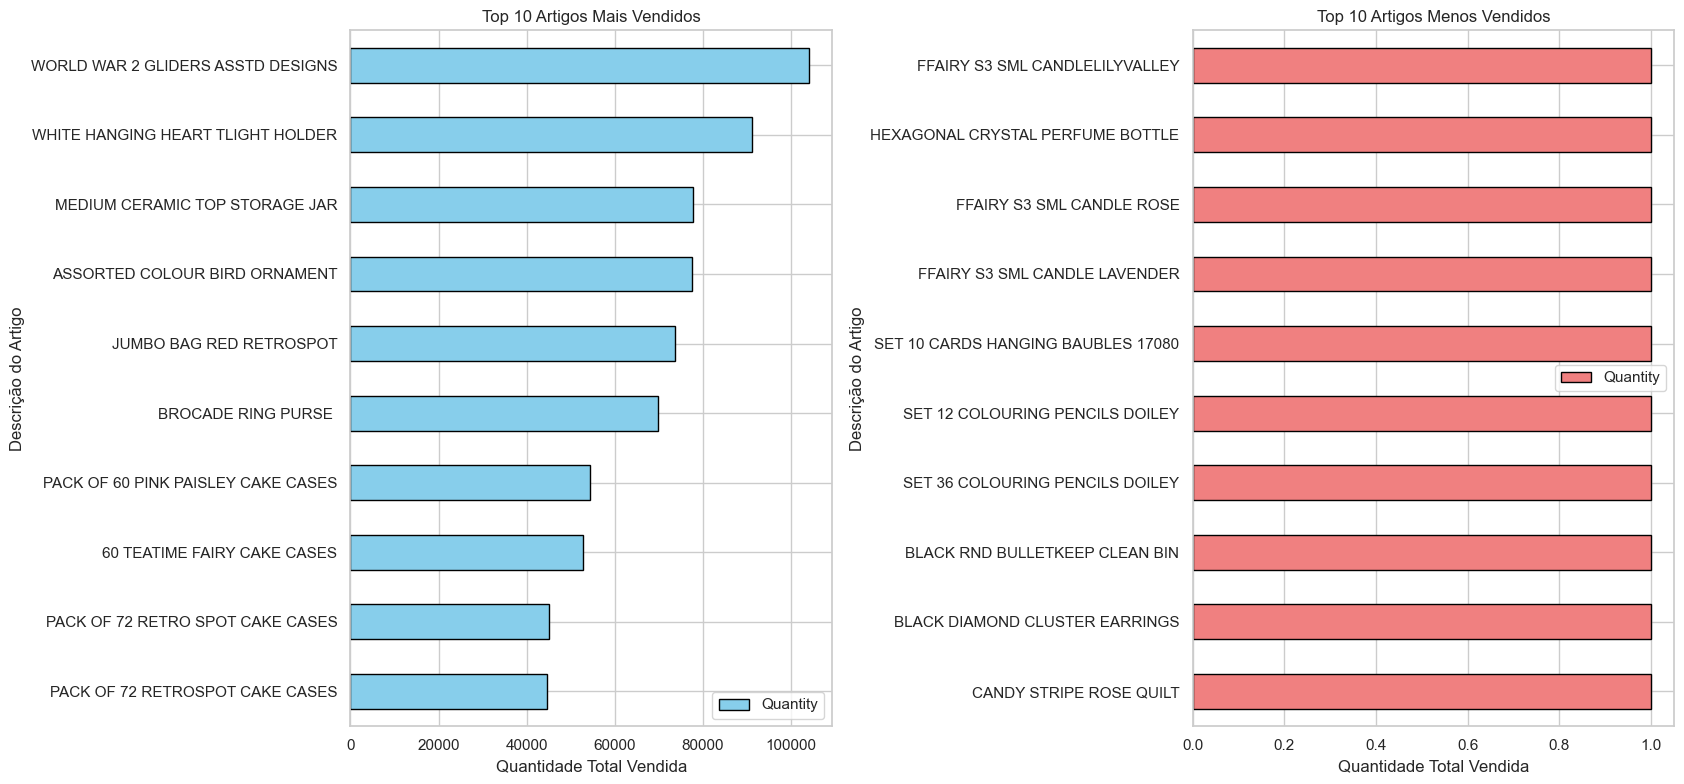

In [137]:
# Selecionar os 10 artigos mais vendidos
top_10_sales_by_description = total_sales_by_description.sort_values(ascending=False).head(10)

# Selecionar os 10 artigos menos vendidos
bottom_10_sales_by_description = total_sales_by_description.sort_values(ascending=True).head(10)

# Criar gráfico de barras horizontais para o top 10
plt.figure(figsize=(17, 8))

# Top 10
plt.subplot(1, 2, 1)
top_10_sales_by_description.sort_values().plot.barh(color='skyblue', edgecolor='black')
plt.xlabel('Quantidade Total Vendida')
plt.ylabel('Descrição do Artigo')
plt.title('Top 10 Artigos Mais Vendidos')
plt.legend()
plt.tight_layout()

# Bottom 10
plt.subplot(1, 2, 2)
bottom_10_sales_by_description.sort_values().plot.barh(color='lightcoral', edgecolor='black')
plt.xlabel('Quantidade Total Vendida')
plt.ylabel('Descrição do Artigo')
plt.title('Top 10 Artigos Menos Vendidos')
plt.legend()
plt.tight_layout()

plt.show()

##### Top 10 Artigos Mais Vendidos:
Produto Mais Vendido: Como já verificado anteriormente é o "WORLD WAR 2 GLIDERS ASSTD DESIGNS", com uma quantidade visivelmente maior que os demais.
Produto Menos Vendido (do Top 10): Entre os mais vendidos, o item "PACK OF 72 RETROSPOT CAKE CASES" é o que tem menor quantidade dentro do top 10, encontrando-se nas 2 últimas posições (Ambos os artigos apresentam nomes muito parecidos).
Popularidade: Produtos relacionados a utensílios domésticos ou decoração, como o "JUMBO BAG RED RETROSPOT" e "MEDIUM CERAMIC TOP STORAGE JAR", também aparecem entre os mais populares.

##### Top 10 Artigos Menos Vendidos:
Produto Menos Vendido: Todos os produtos nesta lista são o menos vendidos, pois para ambos só soram comprados uma 1 unidade.
Características dos Menos Vendidos: Muitos itens têm foco em produtos de menor utilidade geral, como o "SET 36 COLOURING PENCILS DOILEY" e a "HEXAGONAL CRYSTAL PERFUME BOTTLE".


Comparação Geral:

Produtos de Uso Geral: Os mais vendidos são itens utilitários, com apelo maior a um público amplo (ex.: porta-bolos e itens de organização).
Produtos Decorativos: Tendem a estar entre os menos vendidos, talvez devido à menor demanda ou uso específico.
Insights para Ação:
Promoção de Produtos Menos Vendidos: Focar em marketing e ofertas para os itens decorativos menos vendidos pode ajudar a melhorar seu desempenho.
Aumentar stock de Produtos Populares: O stock dos itens do top 10 mais vendidos deve ser priorizado, especialmente os itens mais comprados como o "PACK OF 72 RETROSPOT CAKE CASES".
Análise de Demanda: Produtos como "CANDY STRIPE ROSE QUILT" talvez precisem ser descontinuados ou ajustados para atender às preferências dos consumidores.

### 3. Volume de Vendas

Qual o país que compra mais artigos?

In [138]:
# Agrupar os dados por país e somar a quantidade total de artigos comprados
article_quantity_by_country = data.groupby('Country')['Quantity'].sum().sort_values(ascending=False)

# Converter para um DataFrame e renomear a coluna
article_quantity_by_country_df = pd.DataFrame(article_quantity_by_country)
article_quantity_by_country_df.rename(columns={'Quantity': 'Total Quantity Purchased'}, inplace=True)

# Exibir os dados
article_quantity_by_country_df


,Total Quantity Purchased
Country,
UNITED KINGDOM,8323986
NETHERLANDS,375921
EIRE,314464
FRANCE,267794
DENMARK,237298
GERMANY,221404
AUSTRALIA,103759
SWEDEN,88455
SWITZERLAND,52227


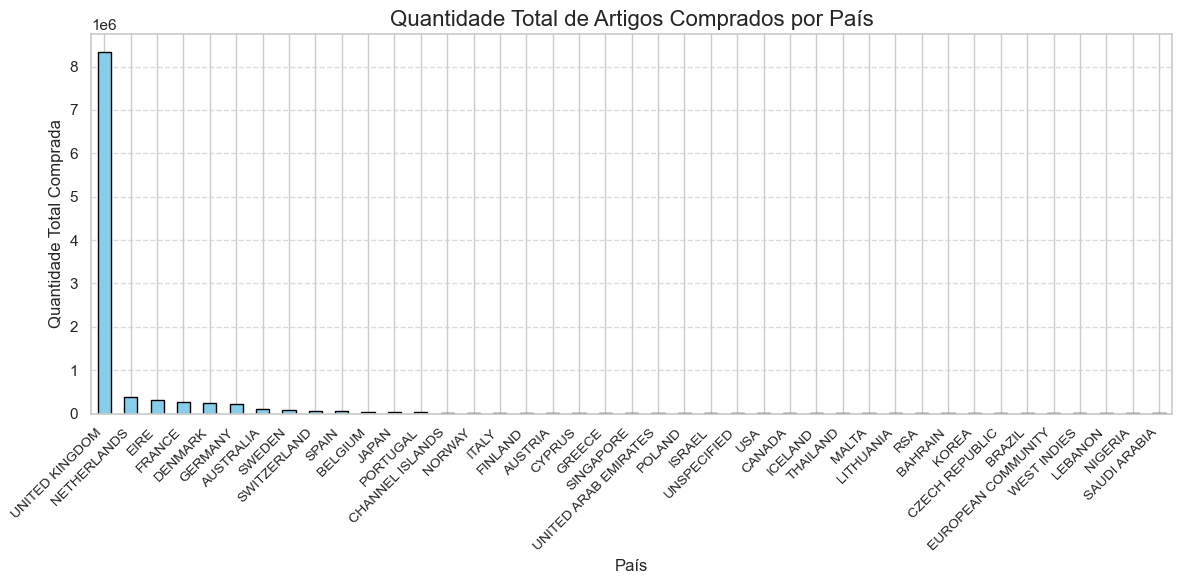

In [139]:
# Criar um gráfico de barras para mostrar a quantidade total de artigos comprados por país
plt.figure(figsize=(12, 6))
article_quantity_by_country.plot(kind='bar', color='skyblue', edgecolor='black')

# Configurações do gráfico
plt.title('Quantidade Total de Artigos Comprados por País', fontsize=16)
plt.xlabel('País', fontsize=12)
plt.ylabel('Quantidade Total Comprada', fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Exibir o gráfico
plt.tight_layout()
plt.show()


Já não sendo novidade nenhuma,o Reino Unido lidera amplamente com mais de 1 milhão de unidades compradas, o que o torna de longe o maior consumidor em termos de quantidades totais.

Existe uma diferença enorme entre o Reino Unido e o segundo país, os Países Baixos, que aparece com um volume significativamente menor.

Outros países, como a França, a Alemanha, e a Irlanda, têm alguma aparência no gráfico, mas a níveis muito mais baixos em comparação ao Reino Unido.
A maioria dos outros países apresenta valores muito pequenos, que mal são percetíveis no gráfico, indicando que o mercado é muito centralizado no Reino Unido.

Em suma, estas informações destacam que o Reino Unido é o principal mercado em termos de volume de compras, o que se deve possivelmente à proximidade do ponto de venda, pois a sede deste e-commerce encontra-se aí, ou, talvez devido a uma maior familiaridade com os produtos por parte do país.

Qual o país compra mais artigos diferenciados?

In [140]:
article_count_by_country = data.groupby('Country')['Description'].nunique().sort_values(ascending=False)
article_count_by_country_df = pd.DataFrame(article_count_by_country)
article_count_by_country_df.rename(columns={'Description': 'Count'}, inplace=True)
article_count_by_country_df

,Count
Country,
UNITED KINGDOM,5196
EIRE,3011
GERMANY,2403
FRANCE,2168
SPAIN,1462
SWITZERLAND,1338
NETHERLANDS,1332
BELGIUM,1069
PORTUGAL,966


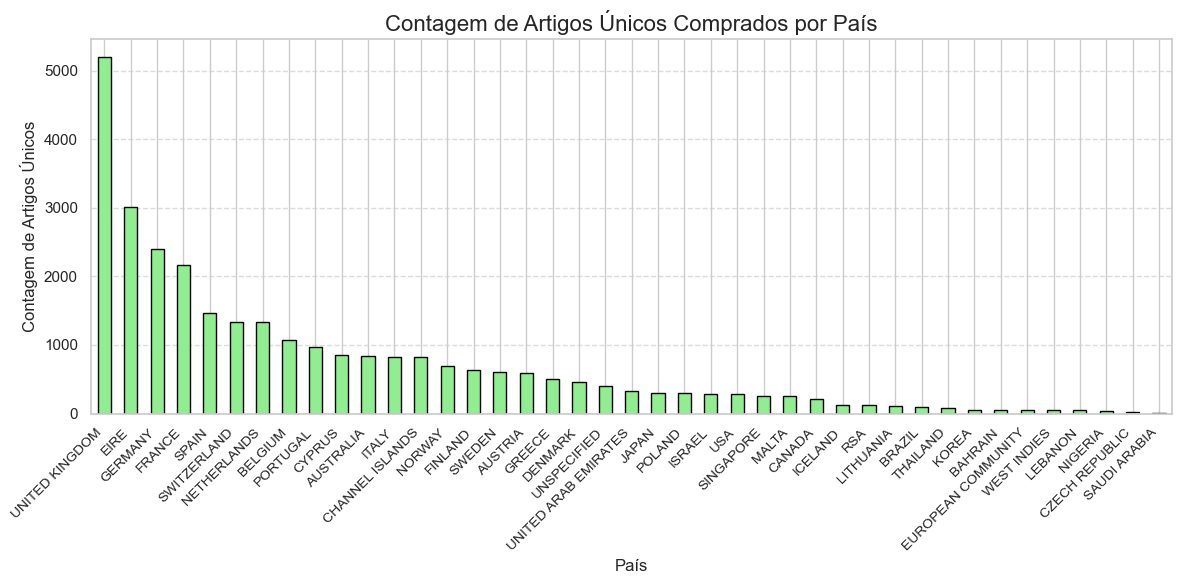

In [141]:
# Criar um gráfico de barras para mostrar a contagem de artigos únicos comprados por país
plt.figure(figsize=(12, 6))
article_count_by_country.plot(kind='bar', color='lightgreen', edgecolor='black')

# Configurações do gráfico
plt.title('Contagem de Artigos Únicos Comprados por País', fontsize=16)
plt.xlabel('País', fontsize=12)
plt.ylabel('Contagem de Artigos Únicos', fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Exibir o gráfico
plt.tight_layout()
plt.show()

Neste caso o Reino Unido também lidera na diversidade de produtos adequiridos, com mais de 5000 artigos únicos adquiridos.

Países como a Alemanha, a França, e os Países Baixos aparecem com uma contagem significativa de artigos únicos, o que sugere que há interesse numa maior variedade de produtos nesses mercados e dando mais destaque aos restantes países europeus.
Maior Distribuição da Diversidade:
Para além disso, neste gráfico pode-se analisar uma maior distribuição de diversidade de produtos em comparação com o primeiro gráfico. A diferença entre o Reino Unido e os outros países não é tão drástica, o que sugere que, embora o Reino Unido compre mais em volume, outros países focam-se mais em diversificar mais suas compras. Mercados como o da Alemanha, França, e Suíça demonstram interesse em artigos mais variados, mesmo que os volumes sejam menores.

Vai-se criar uma tabela cruzada, de modo a vizualizar melhor os resultados juntos:

In [172]:
# Agrupando por 'Country' e contando o número de artigos
article_count_by_country_df = data.groupby('Country').size().to_frame(name='Total Articles').sort_values('Total Articles', ascending=False)

# Agrupando por país e obtendo o artigo mais vendido
max_sales_grouped = max_sales_by_country.groupby('Country')['Description'].first().reset_index()

# Calculando a quantidade de vendas por país
article_sales_count = sales_by_description.groupby('Country')['Quantity'].sum().reset_index()
article_sales_count.rename(columns={'Quantity': 'Total Articles Purchased'}, inplace=True)

# Merge para incluir o artigo mais vendido e quantidade de vendas ao 'article_count_by_country_df'
cross_table = article_count_by_country_df.merge(max_sales_grouped, on='Country', how='left').merge(article_sales_count, on='Country', how='left')

cross_table.rename(columns={'Description': 'Top Article'}, inplace=True)

print("Contagem de artigos, vendas e artigo mais vendido por país:")
cross_table

Contagem de artigos, vendas e artigo mais vendido por país:


,Country,Total Articles,Top Article,Total Articles Purchased
0,UNITED KINGDOM,689567,WORLD WAR 2 GLIDERS ASSTD DESIGNS,8323986
1,GERMANY,16153,ROUND SNACK BOXES SET OF4 WOODLAND,221404
2,EIRE,15280,60 TEATIME FAIRY CAKE CASES,314464
3,FRANCE,13284,SET6 FRUIT SALAD PAPER CUPS,267794
4,NETHERLANDS,4999,FOLKART ZINC HEART CHRISTMAS DEC,375921
5,SPAIN,3597,FRENCH WC SIGN BLUE METAL,50033
6,SWITZERLAND,3005,PLASTERS IN TIN WOODLAND ANIMALS,52227
7,BELGIUM,2988,DOLLY GIRL LUNCH BOX,34169
8,PORTUGAL,2303,JUMBO SHOPPER VINTAGE RED PAISLEY,26886
9,AUSTRALIA,1789,MINI PAINT SET VINTAGE,103759


#### Volume x Diversidade:

O Reino Unido lidera tanto em volume total quanto em diversidade de produtos. Contudo, o domínio em volume é muito mais acentuado do que em diversidade.

Países como os Países Baixos e França apresentam altos volumes no primeiro gráfico, mas não possuem a mesma posição no segundo gráfico, indicando que podem estar focados em comprar maiores quantidades de um menor número de produtos.
Por outro lado, países como a Alemanha e a Suíça, com posições mais destacadas no segundo gráfico, demonstram um interesse em explorar uma maior variedade de artigos, mesmo com volumes menores.

O primeiro gráfico evidencia uma grande dependência do mercado do Reino Unido em termos de vendas totais. Já o segundo gráfico sugere que há oportunidades para expandir a variedade de produtos para outros países.

Mercados com uma maior diversidade de compras (segundo gráfico) podem ser explorados para aumentar o volume de vendas, enquanto países com altos volumes (primeiro gráfico) podem ser incentivados a comprar uma maior diversidade de produtos.

Com base em todas as análises realizadas até agora podemos concluir que o "United Kingdom" está sempre presente nos resultados mais elevados, o que o torna o país mais popular, logo vamos realizar uma análise mais aprofundada dentro desse país.

## 3. **Análise das compras realizadas pelo "UNITED KINGDOM":** 

In [143]:
# Filtrar apenas os registros para o "United Kingdom"
uk_data = total_shops[total_shops['Country'] == 'UNITED KINGDOM']
uk_data1 = data[data['Country'] == 'UNITED KINGDOM']
uk_data

,Invoice,Customer ID,InvoiceDate,Articles,TotalArtQuant,TotalValue,Country,TransactionSize,ShopSize
0,489434,13085,2009-12-01 07:45:00,8,166,505.30,UNITED KINGDOM,Normal,Pequena
1,489435,13085,2009-12-01 07:46:00,4,60,145.80,UNITED KINGDOM,Pequena,Pequena
2,489436,13078,2009-12-01 09:06:00,19,193,630.33,UNITED KINGDOM,Grande,Pequena
3,489437,15362,2009-12-01 09:08:00,23,145,310.75,UNITED KINGDOM,Pequena,Pequena
4,489438,18102,2009-12-01 09:24:00,17,826,2286.24,UNITED KINGDOM,Grande,Grande
...,...,...,...,...,...,...,...,...,...
36516,580482,16033,2011-12-04 12:44:00,73,206,421.87,UNITED KINGDOM,Normal,Pequena
36517,580490,15773,2011-12-04 12:48:00,10,311,635.68,UNITED KINGDOM,Grande,Grande
36518,580500,17131,2011-12-04 12:52:00,52,418,1067.33,UNITED KINGDOM,Grande,Grande
36519,580501,14546,2011-12-04 13:00:00,70,231,495.83,UNITED KINGDOM,Normal,Pequena


In [144]:
uk_data.describe()

,Customer ID,InvoiceDate,Articles,TotalArtQuant,TotalValue
count,33141.000000,33141,33141.000000,33141.000000,33141.000000
mean,15512.279925,2010-12-19 16:37:02.838779904,20.499955,251.168824,422.737931
min,12346.000000,2009-12-01 07:45:00,1.000000,1.000000,0.380000
25%,14092.000000,2010-06-23 16:52:00,6.000000,71.000000,153.150000
50%,15513.000000,2010-11-25 18:16:00,15.000000,146.000000,298.320000
75%,16931.000000,2011-06-30 12:42:00,27.000000,273.000000,448.450000
max,18287.000000,2011-12-04 13:15:00,541.000000,87167.000000,77183.600000
std,1626.554618,NaN,22.140246,813.630739,908.228266


Pontos chave a reter:

- De todas as transações do dataset, 33141 pertencem ao Reino Unido, tendo a primeira ocorrido a 1 de dezembro de 2009 e a última a 4 de dezembro de 2011, abrangendo 2 anos completos.
- A quantidade média de artigos comprados por transação é de 20,5 artigos. Porém, há uma grande variação, O mínimo é 1 artigo, enquanto o máximo é 541 artigos numa única transação.
- O desvio padrão (22,14) indica alta dispersão, ou seja, algumas transações envolvem muitos artigos, mas a maioria é menor.
- A quantidade média de itens vendidos por transação é de 251 unidades.
- 50% das transações envolvem até 146 unidades, mas o máximo chega a 87167 unidades, indicando a presença de transações excepcionalmente grandes que distorcem a média.
- O desvio padrão de 813,63 reforça essa alta variabilidade.
- O valor médio por transação é de 422,74£ e varia significativamente,  mínimo é 0,38£, sugerindo transações de baixo valor.
- 50% das transações apresentam um valor abaixo de 298,32£, enquanto o máximo é 77183,60£, demonstrando a presença de algumas transações extremamente altas.
- O desvio padrão de 908,23 também evidencia a dispersão dos valores das transações.

A análise dos quartis fornece uma visão clara do comportamento típico das transações:
- 25% mais baixas:
Até 6 artigos, 71 unidades, e um valor total de até 153,15.
- 50% (mediana):
Envolvem 15 artigos, 146 unidades, e têm um valor total de 298,32.
- 25% mais altas:
Mais de 27 artigos, 273 unidades, e valores acima de 448,45.
(Sugere que a maioria das transações se encontra num intervalo moderado, enquanto as transações muito grandes (com valores e quantidades extremas) são raras.)

Vai-se agora é analisar mais a fundo o comportamento dos clientes deste país.

In [145]:
# Verificar se há registros para o "United Kingdom"
if uk_data.empty:
    print("Não há registros para 'United Kingdom'.")
else:
    # Total gasto por cada cliente (sum of 'TotalValue' for each 'Customer ID')
    total_spent_by_customer = uk_data.groupby('Customer ID')['TotalValue'].sum()

    # Cliente que gastou mais
    top_spender = total_spent_by_customer.idxmax()
    top_spender_total = total_spent_by_customer[top_spender]

    # Contagem de artigos comprados por cliente
    articles_count_by_customer = uk_data.groupby('Customer ID')['TotalArtQuant'].sum()

    # Cliente que comprou mais artigos
    top_article_count_customer = articles_count_by_customer.idxmax()
    top_article_count = articles_count_by_customer[top_article_count_customer]

    # Contagem de variedade de artigos comprados por cliente
    unique_articles_count_by_customer = uk_data1.groupby('Customer ID')['Description'].nunique()

    # Cliente que comprou a maior variedade de artigos
    top_variety_customer = unique_articles_count_by_customer.idxmax()
    top_variety_count = unique_articles_count_by_customer[top_variety_customer]

    print(f"Cliente que fez a compra de valor mais alto:\nCustomer ID: {top_spender} - Total Gasto: {top_spender_total}")
    print(f"\nCliente que comprou mais artigos:\nCustomer ID: {top_article_count_customer} - Número de Artigos: {top_article_count}")
    print(f"\nCliente que comprou a maior variedade de artigos:\nCustomer ID: {top_variety_customer} - Variedade de Artigos: {top_variety_count}")


Cliente que fez a compra de valor mais alto:
Customer ID: 18102 - Total Gasto: 569501.5

Cliente que comprou mais artigos:
Customer ID: 13694 - Número de Artigos: 185761

Cliente que comprou a maior variedade de artigos:
Customer ID: 12748 - Variedade de Artigos: 2351


In [146]:
 # Criar a tabele
pivot_table = pd.DataFrame({
    'Total Value': total_spent_by_customer,
    'Articles Count': articles_count_by_customer,
    'Unique Articles Count': unique_articles_count_by_customer
})

print("Estatísticas por Cliente no Reino Unido:")
print(pivot_table)

Estatísticas por Cliente no Reino Unido:
             Total Value  Articles Count  Unique Articles Count
Customer ID                                                    
12346           77556.46           74285                     26
12608             415.79             323                     16
12745             723.85             467                     20
12746             254.55              97                     17
12747            8459.98            2518                     90
...                  ...             ...                    ...
18283            2456.90            1537                    368
18284             461.68             494                     28
18285             427.00             145                     12
18286            1296.43             608                     67
18287            4182.99            3013                    120

[5337 rows x 3 columns]


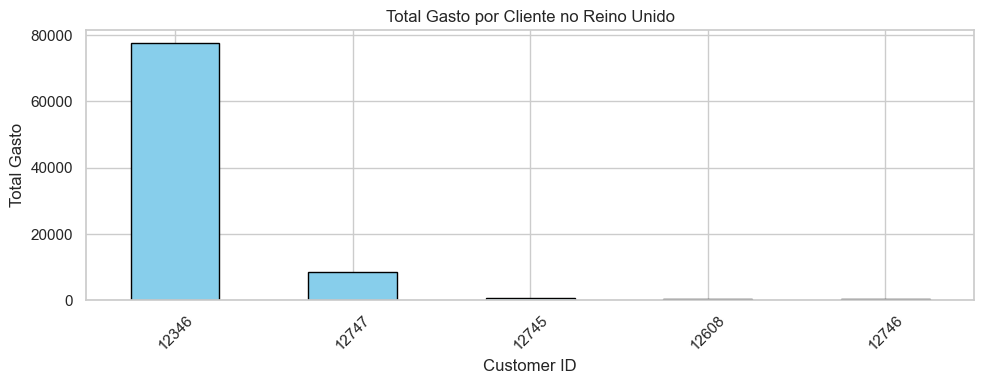

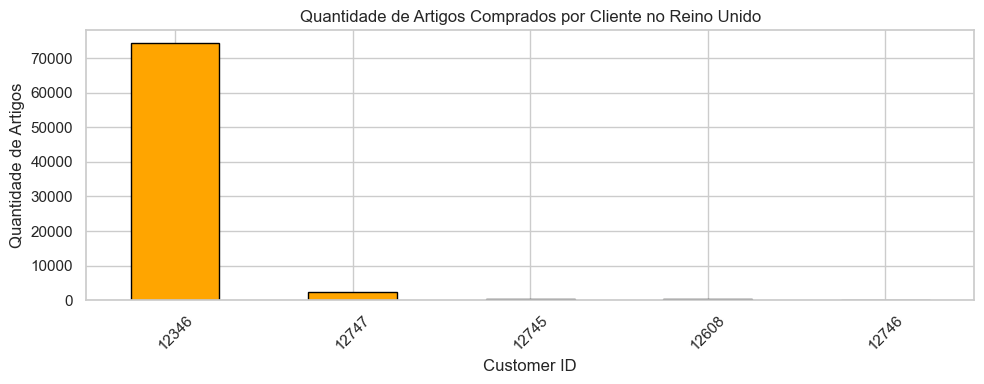

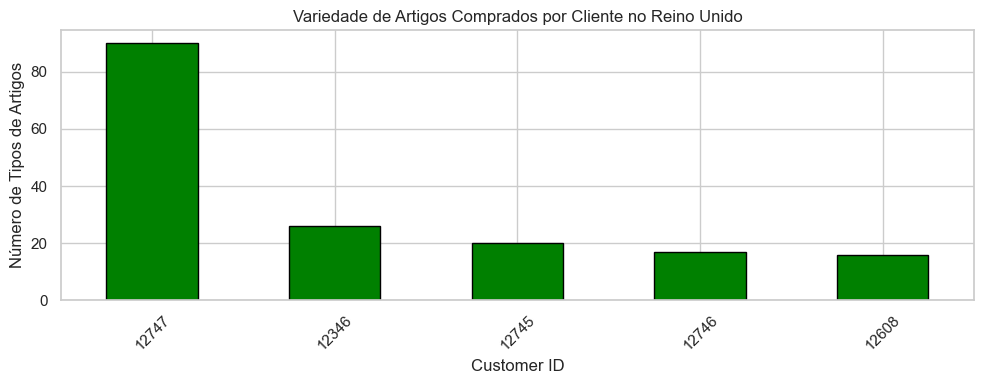

In [147]:
# Gráfico 1: Total gasto por cliente
total_spent_by_customer = total_spent_by_customer.head(5)
plt.figure(figsize=(10, 4))
total_spent_by_customer.sort_values(ascending=False).plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Total Gasto por Cliente no Reino Unido')
plt.xlabel('Customer ID')
plt.ylabel('Total Gasto')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Gráfico 2: Número de artigos comprados por cliente
articles_count_by_customer = articles_count_by_customer.head(5)
plt.figure(figsize=(10, 4))
articles_count_by_customer.sort_values(ascending=False).plot(kind='bar', color='orange', edgecolor='black')
plt.title('Quantidade de Artigos Comprados por Cliente no Reino Unido')
plt.xlabel('Customer ID')
plt.ylabel('Quantidade de Artigos')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Gráfico 3: Variedade de artigos comprados por cliente
unique_articles_count_by_customer = unique_articles_count_by_customer.head(5)
plt.figure(figsize=(10, 4))
unique_articles_count_by_customer.sort_values(ascending=False).plot(kind='bar', color='green', edgecolor='black')
plt.title('Variedade de Artigos Comprados por Cliente no Reino Unido')
plt.xlabel('Customer ID')
plt.ylabel('Número de Tipos de Artigos')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

1. Total Gasto por Cliente no Reino Unido (Gráfico 1)
O cliente com o maior gasto é o 12346, com um total muito superior em relação aos demais, o que indica que provavelmente se trata de uma empresa ou comprador atacadista.
Outros clientes, como o 12747 e 12745, apresentam valores de gasto significativamente menores, mas ainda são os principais contribuidores após o cliente 12346.
A diferença entre o maior e os outros clientes é muito acentuada, sugerindo uma grande concentração de receitas num único cliente.

2. Quantidade de Artigos Comprados por Cliente no Reino Unido (Gráfico 2)
O cliente 12346 também lidera em quantidade total de artigos comprados, com mais de 70000 unidades adquiridas.
Clientes como 12747 e 12745 compraram uma quantidade consideravelmente menor, refletindo o padrão do gráfico anterior.
A dominância do cliente 12346 nas duas métricas (gasto e quantidade) reforça a ideia de que é um comprador em larga escala.

3. Variedade de Artigos Comprados por Cliente no Reino Unido (Gráfico 3)
Curiosamente, o cliente com maior variedade de artigos comprados é o 12747, com mais de 80 tipos de artigos diferentes adquiridos.
O cliente 12346, apesar de ter o maior gasto e quantidade de artigos comprados, apresenta uma variedade menor de itens adquiridos, indicando que sua compra pode estar concentrada em poucos produtos em grandes volumes, ou seja, deve ser uma empresa que só precisa de um certo tipo especifico de asrtigos.
Os outros clientes analisados (como 12745, 12746, e 12346) apresentam uma variedade de artigos semelhante, com cerca de 20-30 tipos diferentes.


Em suma, o cliente 12346 parece ser o principal responsável pelo volume de vendas, sendo um elemento crucial para o negócio. No entanto, a dependência do mesmo em função do lucro do negócio pode ser um risco se a qualquer momento houver uma queda nas suas compras. É melhor começar a apostar em outros clientes.
Clientes como o 12747, que realizam compras com uma maior diversidade, representam uma base interessante para poder aplicar estratégias de marketing focadas numa fidelização e diversificação, de modo a vir poder aumentar as vendas.

## 4. **Análise de Séries Temporais:**

A análise de séries temporais é uma técnica estatística utilizada para analisar dados que são recolhidos ao longo do tempo. O objetivo principal dessa análise é entender padrões e comportamentos dos dados ao longo do tempo, com o intuito de fazer previsões futuras, identificar tendências e ciclos.

Para a análise deste conjunto de dados ir-se-á realizar uma análise das vendas realizadas, anualmente, mensalmente e semanalmente (de acordo com os dias da semana).

Primeiro, de modo a ficilitar a análise vai-se adicionar novas colunas dataframe original "data":

In [148]:
# Criar novas colunas para análise temporal
total_shops['Year'] = total_shops['InvoiceDate'].dt.year
total_shops['Month'] = total_shops['InvoiceDate'].dt.month
total_shops['Day'] = total_shops['InvoiceDate'].dt.day
total_shops['Weekday'] = total_shops['InvoiceDate'].dt.day_name()
total_shops['Hour'] = total_shops['InvoiceDate'].dt.strftime('%H:%M')
total_shops.head()

,Invoice,Customer ID,InvoiceDate,Articles,TotalArtQuant,TotalValue,Country,TransactionSize,ShopSize,Year,Month,Day,Weekday,Hour
0,489434,13085,2009-12-01 07:45:00,8,166,505.30,UNITED KINGDOM,Normal,Pequena,2009,12,1,Tuesday,07:45
1,489435,13085,2009-12-01 07:46:00,4,60,145.80,UNITED KINGDOM,Pequena,Pequena,2009,12,1,Tuesday,07:46
2,489436,13078,2009-12-01 09:06:00,19,193,630.33,UNITED KINGDOM,Grande,Pequena,2009,12,1,Tuesday,09:06
3,489437,15362,2009-12-01 09:08:00,23,145,310.75,UNITED KINGDOM,Pequena,Pequena,2009,12,1,Tuesday,09:08
4,489438,18102,2009-12-01 09:24:00,17,826,2286.24,UNITED KINGDOM,Grande,Grande,2009,12,1,Tuesday,09:24


As colunas adicionadas representam o seguinte:
- "Year": Ano em que foram realizadas as compras
- "Month": Mês em que foram realizadas as compras
- "Day": Dia do mês em que foram realizadas as compras
- "Weekday": Dia da semana em que foram realizadas as compras
- "Hour": Hora do dia em que foram realizadas as compras

#### 1. Análise Anual:

In [149]:
# Calcula a soma dos valores arrecadados por ano
total_per_year = total_shops.groupby('Year')['TotalValue'].sum().reset_index()
print("Soma dos Valores Arrecadados por Ano:")
total_per_year

Soma dos Valores Arrecadados por Ano:


,Year,TotalValue
0,2009,683504.010
1,2010,8374496.094
2,2011,7898900.844


In [150]:
total_revenue = total_per_year.sum()
print(f"\nValor total das vendas:{total_revenue}")


Valor total das vendas:Year          6.030000e+03
TotalValue    1.695690e+07
dtype: float64


O valor total arrecadado ao longo dos 3 anos é igual a 16956900£.

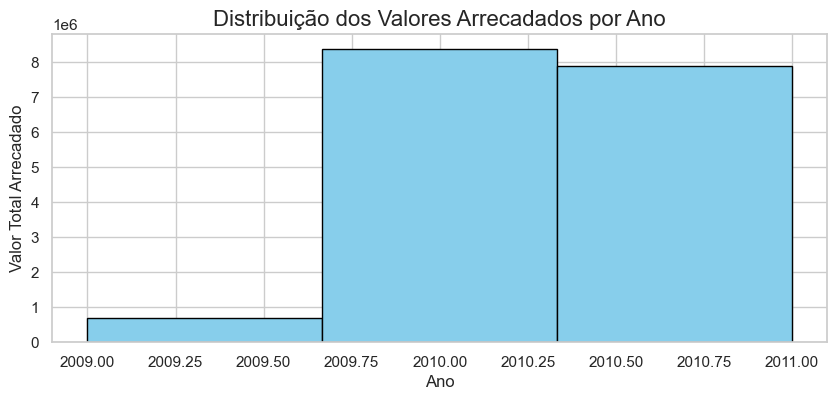

In [151]:
# Supondo que 'total_per_year' seja o DataFrame já obtido com a soma dos valores por ano
plt.figure(figsize=(10, 4))

# Criando um histograma com a soma dos valores por ano
plt.hist(total_per_year['Year'], bins=len(total_per_year['Year'].unique()), weights=total_per_year['TotalValue'], color='skyblue', edgecolor='black')

# Adicionando título e rótulos aos eixos
plt.title('Distribuição dos Valores Arrecadados por Ano', fontsize=16)
plt.xlabel('Ano', fontsize=12)
plt.ylabel('Valor Total Arrecadado', fontsize=12)

# Exibindo o gráfico
plt.show()

O histograma evidencia a distribuição dos valores arrecadados ao longo dos anos. Observa-se que a maior parte das receitas foi gerada entre 2010 e 2011, tendo 2010 um destaque mais significativo em relação ao ano anterior (2009).
A ausência de valores expressivos em 2009, é devido ao facto de os dados só começarem a partir de dezembro de 2009, logo é obvio que esse ano ia sempre ter um volume de vendas muito reduzido.

De 2010 para 2011 houve uma descida dos valores de vendas, tal pode-se dever ao facto de o conjunto de dados só ir até 04/12 de 2011, o que acaba a não considerar o mês de dezembro.

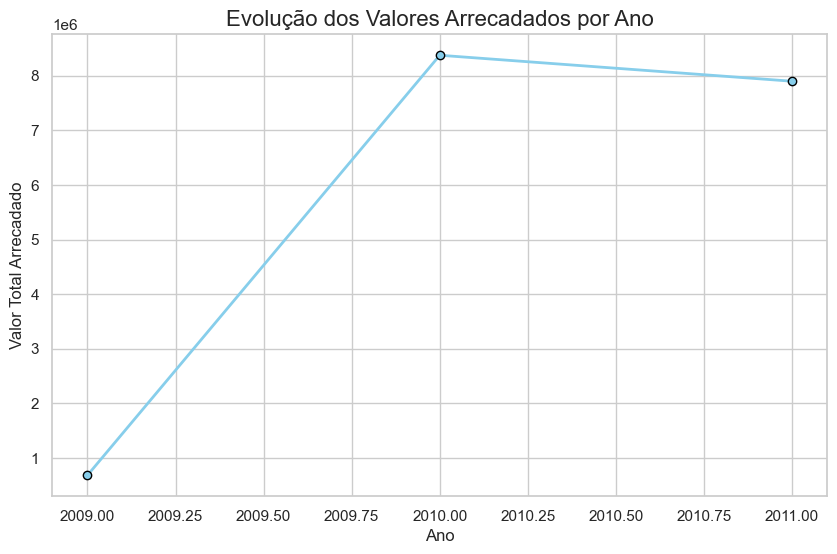

In [152]:
# Supondo que 'total_per_year' seja o DataFrame com a soma dos valores por ano
plt.figure(figsize=(10, 6))

# Criando o gráfico de linhas
plt.plot(total_per_year['Year'], total_per_year['TotalValue'], marker='o', linestyle='-', color='skyblue', markersize=6, linewidth=2, markeredgecolor='black')

# Adicionando título e rótulos aos eixos
plt.title('Evolução dos Valores Arrecadados por Ano', fontsize=16)
plt.xlabel('Ano', fontsize=12)
plt.ylabel('Valor Total Arrecadado', fontsize=12)

# Exibindo o gráfico
plt.grid(True)
plt.show()

Média, Mediana e Variância dos valores totais das transações:

In [153]:
transaction_stats_per_year = total_shops.groupby('Year')['TotalValue'].agg(['mean', 'median', 'var'])

# Exibindo o resultado
print(transaction_stats_per_year)

            mean  median           var
Year                                  
2009  451.754137  304.20  6.365580e+05
2010  456.152083  301.80  8.686723e+05
2011  474.436954  303.56  1.363710e+06


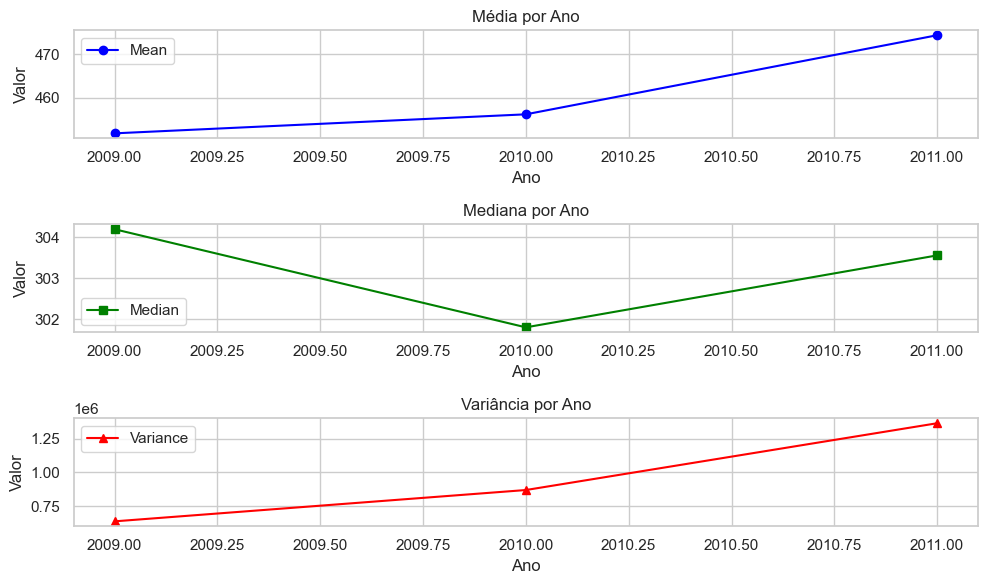

In [154]:
# Criando os subgráficos
fig, axs = plt.subplots(3, 1, figsize=(10, 6))

# Gráfico para 'mean'
axs[0].plot(transaction_stats_per_year.index, transaction_stats_per_year['mean'], label='Mean', color='blue', marker='o')
axs[0].set_title('Média por Ano')
axs[0].set_xlabel('Ano')
axs[0].set_ylabel('Valor')
axs[0].grid(True)
axs[0].legend()

# Gráfico para 'median'
axs[1].plot(transaction_stats_per_year.index, transaction_stats_per_year['median'], label='Median', color='green', marker='s')
axs[1].set_title('Mediana por Ano')
axs[1].set_xlabel('Ano')
axs[1].set_ylabel('Valor')
axs[1].grid(True)
axs[1].legend()

# Gráfico para 'var'
axs[2].plot(transaction_stats_per_year.index, transaction_stats_per_year['var'], label='Variance', color='red', marker='^')
axs[2].set_title('Variância por Ano')
axs[2].set_xlabel('Ano')
axs[2].set_ylabel('Valor')
axs[2].grid(True)
axs[2].legend()

# Ajustando o layout
plt.tight_layout()

# Exibindo os gráficos
plt.show()

- Média por Ano:

O valor médio por compra aumenta continuamente de 2009 a 2011, o que sugere que o valor médio das transações cresce de forma mais estável, independentemente da quantidade de itens.

- Mediana por Ano:

A mediana do valor das compras cresce de forma consistente, indicando que a maior parte das transações envolve valores progressivamente mais altos ao longo dos anos. Este padrão reforça que o aumento do valor médio não é influenciado apenas por compras esporádicas de valores altos, mas por um crescimento geral no valor das transações.

- Variância por Ano:

A variância tem um pico em 2010, mostrando que este ano foi marcado por uma grande dispersão nos valores totais por compra.
A partir de 2010, a variância diminui, indicando que em 2011 as compras foram mais consistentes em termos de valores.

Quantas transações ocorreram por ano?

In [155]:
# Contando o número de transações por ano
transactions_per_year = total_shops.groupby('Year')['Invoice'].count()

# Total de transações
total_transactions = transactions_per_year.sum()

# Calculando a porcentagem de transações por ano
transactions_per_year_percentage = (transactions_per_year / total_transactions) * 100

# Juntando as contagens com as porcentagens
transactions_per_year_with_percentage = pd.DataFrame({
    'Transaction Count': transactions_per_year,
    'Percentage': transactions_per_year_percentage
})

# Exibindo o resultado
print(transactions_per_year_with_percentage)

      Transaction Count  Percentage
Year                               
2009               1513    4.142822
2010              18359   50.269708
2011              16649   45.587470


Quantos artigos foram comprados por ano?

In [156]:
# Certificando-se de que a coluna 'InvoiceDate' é do tipo datetime
total_shops['InvoiceDate'] = pd.to_datetime(total_shops['InvoiceDate'])

# Extraindo o ano da coluna 'InvoiceDate'
total_shops['Year'] = total_shops['InvoiceDate'].dt.year

# Somando o total de artigos comprados por ano
total_articles_per_year = total_shops.groupby('Year')['TotalArtQuant'].sum()

# Exibindo o resultado
print(total_articles_per_year)

Year
2009     398660
2010    5274337
2011    4609740
Name: TotalArtQuant, dtype: int64


In [157]:
transaction_stats_per_year = total_shops.groupby('Year')['TotalArtQuant'].agg(['mean', 'median', 'var'])

# Exibindo o resultado
print(transaction_stats_per_year)

            mean  median           var
Year                                  
2009  263.489755   143.0  6.552464e+05
2010  287.288905   146.0  2.064049e+06
2011  276.877891   158.0  6.360739e+05


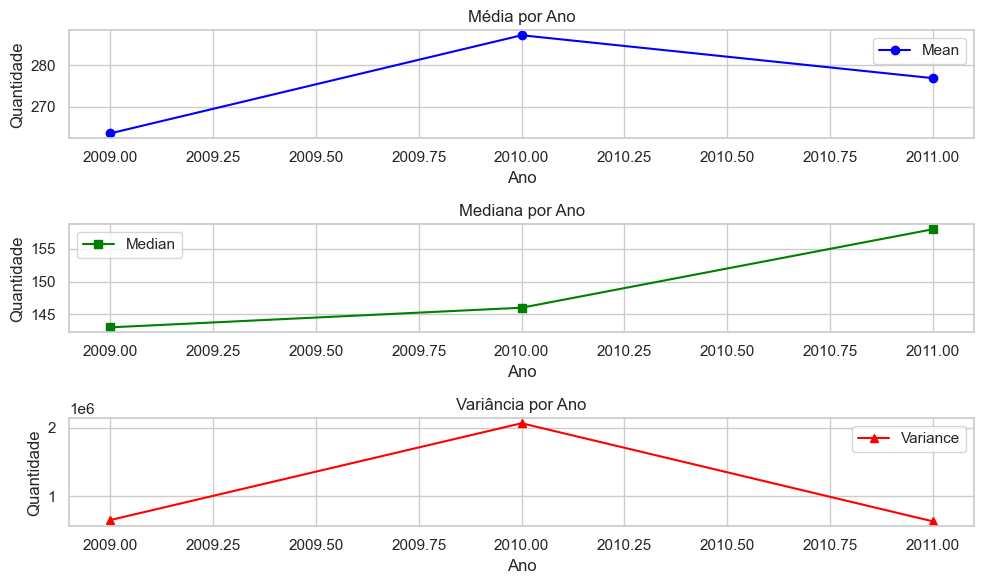

In [158]:
# Criando os subgráficos
fig, axs = plt.subplots(3, 1, figsize=(10, 6))

# Gráfico para 'mean'
axs[0].plot(transaction_stats_per_year.index, transaction_stats_per_year['mean'], label='Mean', color='blue', marker='o')
axs[0].set_title('Média por Ano')
axs[0].set_xlabel('Ano')
axs[0].set_ylabel('Quantidade')
axs[0].grid(True)
axs[0].legend()

# Gráfico para 'median'
axs[1].plot(transaction_stats_per_year.index, transaction_stats_per_year['median'], label='Median', color='green', marker='s')
axs[1].set_title('Mediana por Ano')
axs[1].set_xlabel('Ano')
axs[1].set_ylabel('Quantidade')
axs[1].grid(True)
axs[1].legend()

# Gráfico para 'var'
axs[2].plot(transaction_stats_per_year.index, transaction_stats_per_year['var'], label='Variance', color='red', marker='^')
axs[2].set_title('Variância por Ano')
axs[2].set_xlabel('Ano')
axs[2].set_ylabel('Quantidade')
axs[2].grid(True)
axs[2].legend()

# Ajustando o layout
plt.tight_layout()

# Exibindo os gráficos
plt.show()

- Média por Ano:

A média de quantidade por compra aumenta de 2009 até o pico em 2010, e depois diminui ligeiramente em 2011, o que mostra que, em 2010, houve um aumento significativo na quantidade média de artigos comprados, mas que a tendência não se sustentou em 2011.

- Mediana por Ano:

A mediana segue uma tendência crescente ao longo dos anos, indicando que a maior parte das transações passou a incluir mais itens.
Este crescimento mais consistente na mediana, em relação à média, aponta para uma maior uniformidade no número de artigos por compra.

- Variância por Ano:

A variância sofre um pico em 2010, mostrando que este ano foi marcado por uma grande dispersão na quantidade de itens por compra.
A partir de 2010, a variância diminui, indicando que em 2011 as compras foram mais consistentes em termos de número de itens.

Ambos os gráficos mostram uma tendência de aumento na média e na mediana ao longo dos anos, embora a média dos valores tenha um declínio em 2011, enquanto o valor de qunatidade de artigos continua a crescer.

Tanto para quantidade quanto para valor, a variância atinge o pico em 2010, indicando que este ano foi marcado por maior dispersão, com compras variando significativamente tanto em itens quanto em valores.

Em 2011, observa-se que a quantidade média continua a crescer, mesmo com uma leve queda no valor quantidade média de itens por compra,o que indica que os consumidores passam a comprar mais em quantidades unitárias mas menos em termos de valores.

#### 2. Análise Mensal:

In [170]:
# Pivot table: valores totais por ano e mês
pivot_table = total_shops.pivot_table(values='TotalValue', index='Year', columns='Month', aggfunc='sum', fill_value=0)
print(pivot_table)

Month          1           2           3           4          5          6   \
Year                                                                          
2009        0.000       0.000       0.000       0.000       0.00       0.00   
2010   555802.672  504558.956  696978.471  591982.002  597833.38  636371.13   
2011   568101.310  446084.920  594081.760  468374.331  677355.15  660046.05   

Month          7          8           9           10           11         12  
Year                                                                          
2009        0.000       0.00       0.000        0.00        0.000  683504.01  
2010   589736.170  602224.60  829013.951  1033112.01  1166460.022  570422.73  
2011   598962.901  644051.04  950690.202  1035642.45  1156205.610   99305.12  


Dentro de cada ano qual foi o mês em mais se faturou:

In [160]:
# Calcula a soma dos valores arrecadados por mês dentro de cada ano
monthly_sales = total_shops.groupby(['Year', 'Month'])['TotalValue'].sum().unstack().fillna(0)

# Para cada ano, encontrar os meses com os maiores valores de faturamento
top_months_per_year = monthly_sales.apply(lambda x: x.nlargest(1).index.tolist(), axis=1).reset_index()

# Renomeia a segunda coluna para "Mês"
top_months_per_year.rename(columns={0: 'Mês'}, inplace=True)

print("Mês em mais se Faturou:")
top_months_per_year

Mês em mais se Faturou:


,Year,Mês
0,2009,[12]
1,2010,[11]
2,2011,[11]


Como a avaliação das compras só começou a dezembro de 2009, então é óbvio que nesse ano esse foi o mês em que mais se faturou.
Meses de Maior Faturamento:

A tabela destaca que os meses com maior faturamento em cada ano são dezembro (2009) e novembro (2010 e 2011). Esses períodos coincidem com a proximidade do Natal, que é tradicionalmente uma época de alto consumo devido à compra de presentes, decorações e outros itens sazonais.

Em 2010 e 2011, o mês de novembro aparece como o período de maior faturamento, indicando que os clientes começam a antecipar suas compras natalinas. O destaque desses meses reforça a importância de eventos sazonais no comportamento do consumidor. Promoções de Natal e campanhas de marketing provavelmente contribuíram para impulsionar as vendas durante esse período.

Apesar do forte desempenho em novembro e dezembro, é relevante avaliar estratégias para manter um fluxo de faturamento mais consistente em outros meses do ano, diversificando os momentos de maior impacto financeiro.

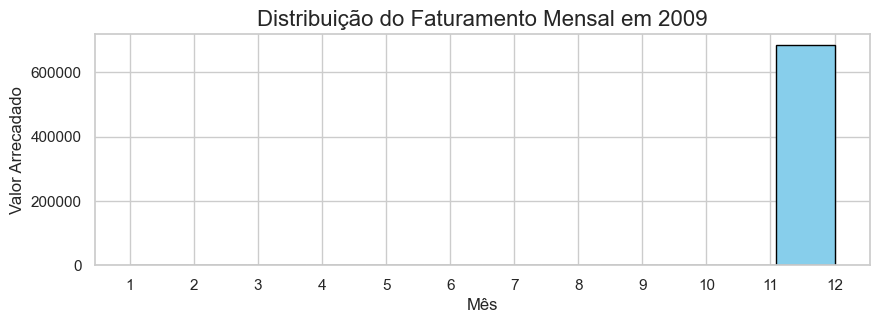

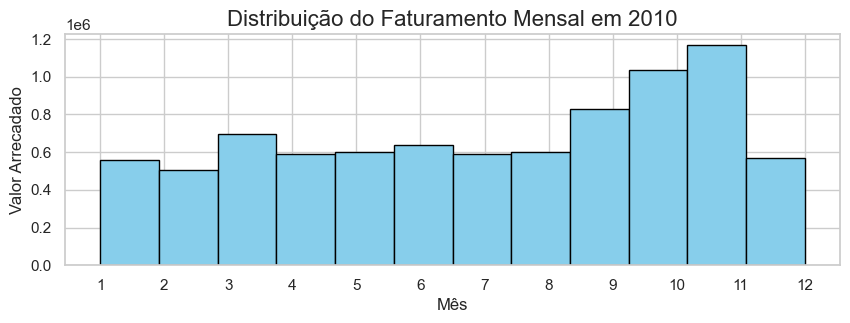

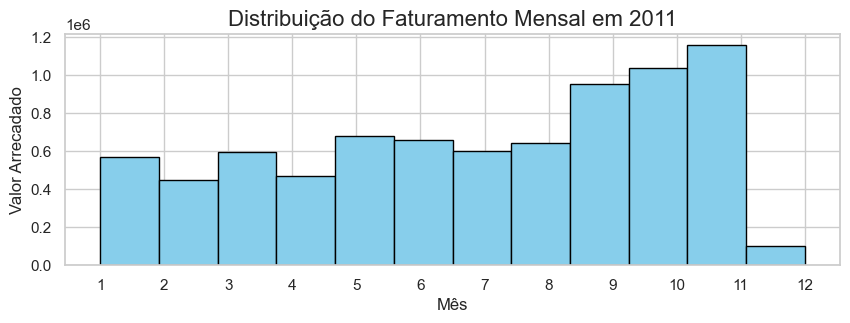

In [161]:
years = monthly_sales.index  # Obtendo os anos disponíveis

# Criando o histograma para cada ano
for year in years[:3]:  # Gerar para os 3 primeiros anos, ajuste conforme necessário
    plt.figure(figsize=(10, 3))
    
    # Extrai os valores do ano específico
    monthly_values = monthly_sales.loc[year]
    
    # Criando o histograma para o ano selecionado
    plt.hist(monthly_values.index, weights=monthly_values.values, bins=12, color='skyblue', edgecolor='black')
    
    # Adicionando título e rótulos aos eixos
    plt.title(f'Distribuição do Faturamento Mensal em {year}', fontsize=16)
    plt.xlabel('Mês', fontsize=12)
    plt.ylabel('Valor Arrecadado', fontsize=12)
    
    # Ajustando os rótulos para exibir os meses no eixo X
    plt.xticks(monthly_values.index, labels=[f'{i+1}' for i in range(12)], rotation=0)
    
    # Exibindo o gráfico
    plt.show()

Em 2010 e 2011 o faturamento encontra-se distribuído ao longo do ano.
O destaque vai para novembro (11), que registra o maior faturamento do ano, seguido de uma queda em dezembro. Esse padrão reflete uma mudança no comportamento do consumidor, provavelmente relacionada à antecipação das compras natalinas por conta de promoções em novembro (como a Black Friday).

Em 2011 há um aumento significativo no faturamento de setembro (9), outubro (10) e principalmente novembro (11), que é o mês de maior faturamento do ano.

Deve-se continuar a investir em campanhas promocionais em novembro, mas também procurar estratégias para fortalecer os meses com menor faturamento (como o início do ano), garantindo assim, uma maior estabilidade financeira ao longo do tempo.

Com base nos meses coincidentes, vai-se avaliar o crescimento das vendas ao longo dos dois anos:

<Figure size 1400x700 with 0 Axes>

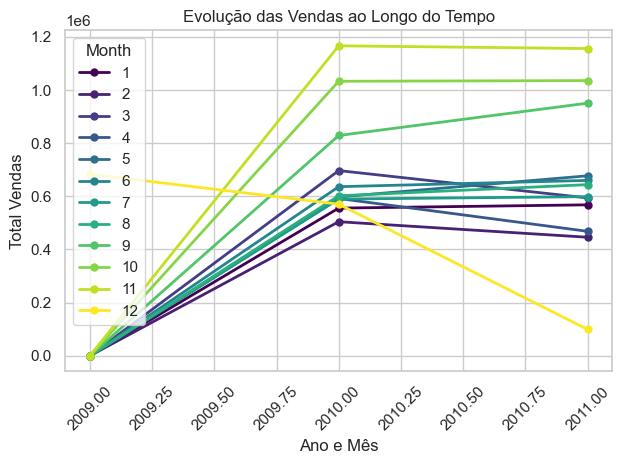

In [162]:
# Calcula a soma dos valores arrecadados por mês dentro de cada ano
monthly_sales = total_shops.groupby(['Year', 'Month'])['TotalValue'].sum().unstack().fillna(0)

# Gera o gráfico contínuo das vendas ao longo do tempo
plt.figure(figsize=(14, 7))
monthly_sales.plot(kind='line', marker='o', linestyle='-', linewidth=2, markersize=5, colormap='viridis')
plt.title('Evolução das Vendas ao Longo do Tempo')
plt.xlabel('Ano e Mês')
plt.ylabel('Total Vendas')
plt.xticks(rotation=45)  # Gira os rótulos do eixo x
plt.tight_layout()
plt.show()

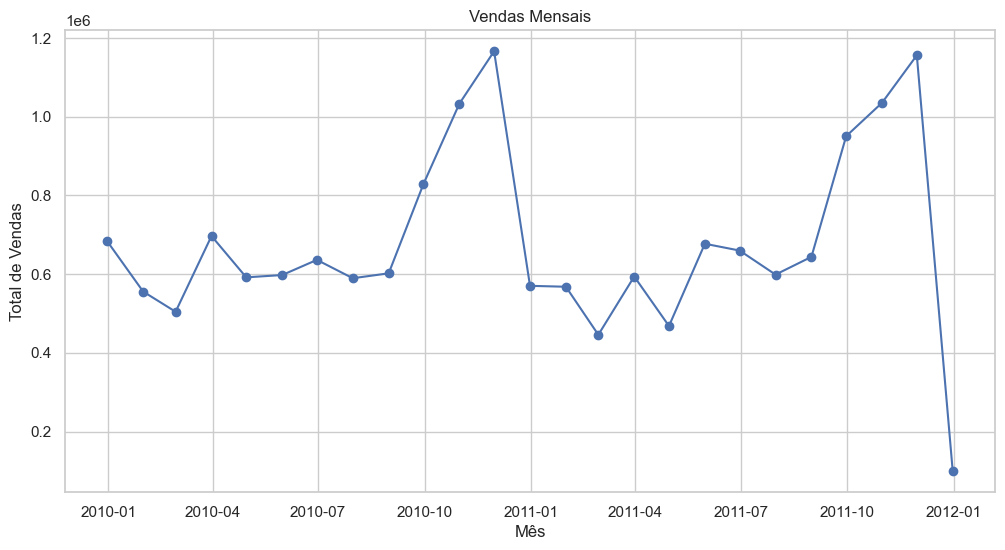

In [163]:
# Resumo mensal das vendas
monthly_sales = total_shops.resample('M', on='InvoiceDate')['TotalValue'].sum()
plt.figure(figsize=(12, 6))
plt.plot(monthly_sales.index, monthly_sales.values, marker='o', linestyle='-')
plt.title('Vendas Mensais')
plt.xlabel('Mês')
plt.ylabel('Total de Vendas')
plt.grid(True)
plt.show()

(Devido a um erro que não foi possível corrigir o gráfico encontra-se um mês à frente, ou seja em vez de ir de Dezembro de 2009 a Dezembro de 2011, vai de janeiro de 2010 a Janeiro de 2012).

Este gráfico demonstra a sazonalidade e flutuações no total de vendas mensais ao longo do tempo (de 2010 a fim de 2011):

Observa-se um padrão geral de estabilidade durante a maior parte do ano, seguido por picos significativos no final de cada ano.

- *Destaques por Ano:*

2010: Relativamente estável, com um leve crescimento nas vendas entre setembro e dezembro. O pico ocorre a novembro de 2010, reforçando o impacto das vendas no final do ano.

2011: Início do ano relativamente estável, semelhante ao ano anterior. A partir de setembro, as vendas começam a crescer de forma mais acentuada, atingindo o pico mais alto do período analisado a novembro de 2011.

Janeiro e fevereiro apresentam consistentemente valores menores de vendas, indicando que esses meses são de menor atividade econômica.

- *Estratégias Recomendadas:*

Aumentar as Vendas no início do ano, talvez lançando campanhas promocionais em janeiro e fevereiro para reduzir o impacto da sazonalidade negativa.
Aproveitar os Picos de Novembro e Dezembro, continuando a fortalecer estratégias durante o período de final de ano, incluindo Black Friday e promoções de Natal.
Estabilizar o Faturamento ao Longo do Ano, criando campanhas sazonais em meses intermediários (junho a agosto) para reduzir a dependência dos picos de final de ano.

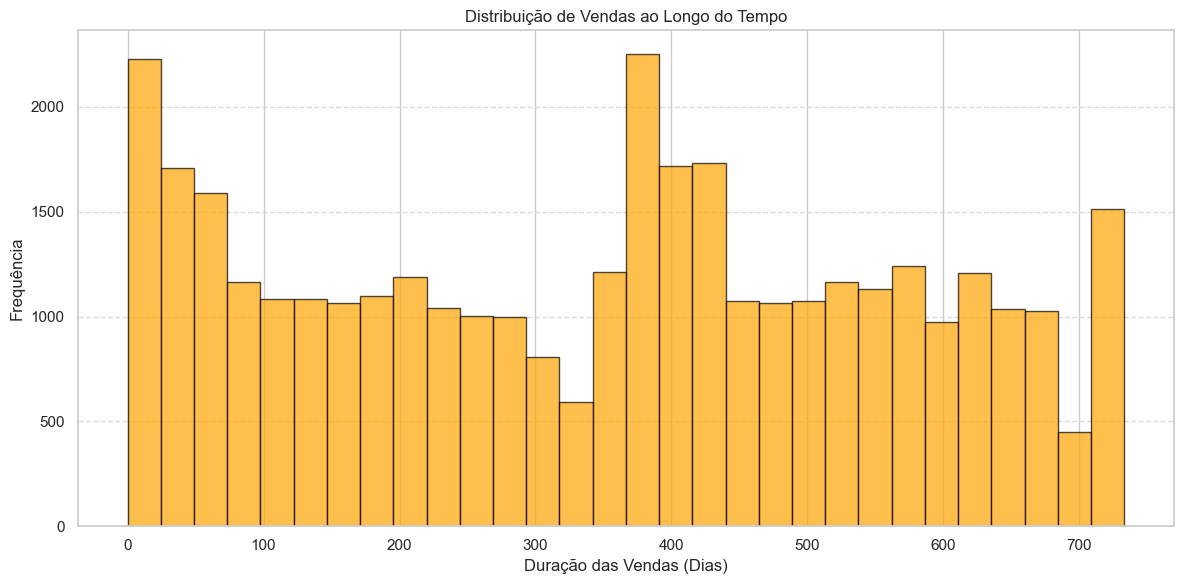

In [164]:
# Calcular a diferença entre as datas de fatura para obter a duração de cada venda
total_shops['InvoiceAge'] = (total_shops['InvoiceDate'].max() - total_shops['InvoiceDate']).dt.days

# Plotar o histograma
plt.figure(figsize=(12, 6))
plt.hist(total_shops['InvoiceAge'], bins=30, color='orange', edgecolor='black', alpha=0.7)
plt.title('Distribuição de Vendas ao Longo do Tempo')
plt.xlabel('Duração das Vendas (Dias)')
plt.ylabel('Frequência')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

#### 3. Análise semanal das vendas

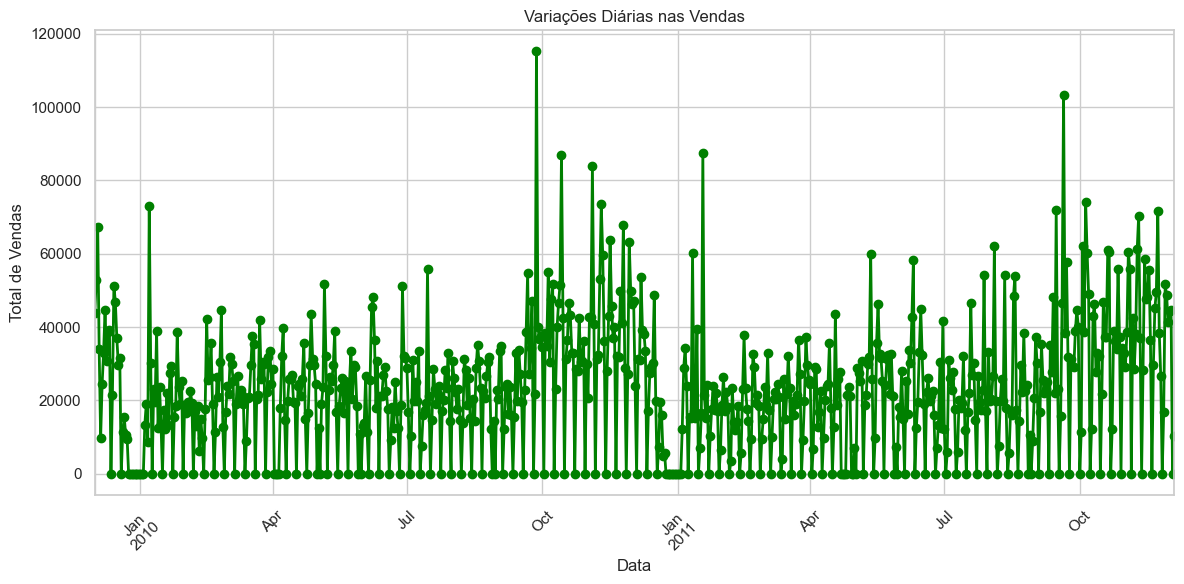

In [165]:
# Obter a soma de vendas diárias
daily_sales = total_shops.resample('D', on='InvoiceDate')['TotalValue'].sum()

# Criar o gráfico de linhas
plt.figure(figsize=(12, 6))
daily_sales.plot(kind='line', color='green', marker='o', linestyle='-', linewidth=2)
plt.title('Variações Diárias nas Vendas')
plt.xlabel('Data')
plt.ylabel('Total de Vendas')
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()


In [166]:
# Obter a soma de vendas diárias
daily_sales = total_shops.resample('D', on='InvoiceDate')['TotalValue'].sum()

# Resetar o índice para facilitar a manipulação
daily_sales = daily_sales.reset_index()

# Adicionar colunas de ano, mês e dia da semana
daily_sales['Year'] = daily_sales['InvoiceDate'].dt.year
daily_sales['Month'] = daily_sales['InvoiceDate'].dt.month_name()
daily_sales['Weekday'] = daily_sales['InvoiceDate'].dt.day_name()

# Criar a cross table (por exemplo: soma total de vendas por mês e dia da semana)
cross_table = daily_sales.pivot_table(
    index='Month',          # Índice: Meses
    columns='Weekday',      # Colunas: Dias da Semana
    values='TotalValue',    # Valores: Total de Vendas
    aggfunc='sum'           # Agregação: Soma
)

# Reordenar os meses para exibição correta
month_order = [
    'January', 'February', 'March', 'April', 'May', 'June',
    'July', 'August', 'September', 'October', 'November', 'December'
]
cross_table = cross_table.reindex(month_order)

# Exibir 
print("Total de Vendas por Mês e Dia da Semana:")
print(cross_table)


Total de Vendas por Mês e Dia da Semana:
Weekday        Friday      Monday  Saturday      Sunday    Thursday  \
Month                                                                 
January    203351.221  131791.140      0.00  113750.540  229735.900   
February   130344.121  192410.842      0.00   90837.991  193340.120   
March      198429.340  206406.621      0.00  114009.630  270919.940   
April      138695.931  173056.621      0.00   89623.660  254914.741   
May        192995.280  171870.770      0.00  155890.400  294529.020   
June       180782.100  211547.900      0.00  141665.110  251879.620   
July       182817.820  188537.530      0.00  138546.810  303345.990   
August     144391.380  178762.150      0.00  140540.020  304679.730   
September  267629.380  349417.141      0.00  171244.571  390679.831   
October    376451.010  363335.240      0.00  243251.150  407871.430   
November   301699.760  375000.501      0.00  235997.950  473486.960   
December   226538.170  177984.020   

Observando a tabela com os totais mensais por dia da semana, verifica-se que meses como outubro e novembro apresentam volumes mais altos de vendas, especialmente durante os dias úteis, possivelmente devido a campanhas sazonais (ex.: Black Friday ou início das compras de final de ano).
O padrão de vendas mais fortes durante os dias úteis é visível nesta tabela.

Gráfico de Barras para Comportamento de Compra ao Longo da Semana

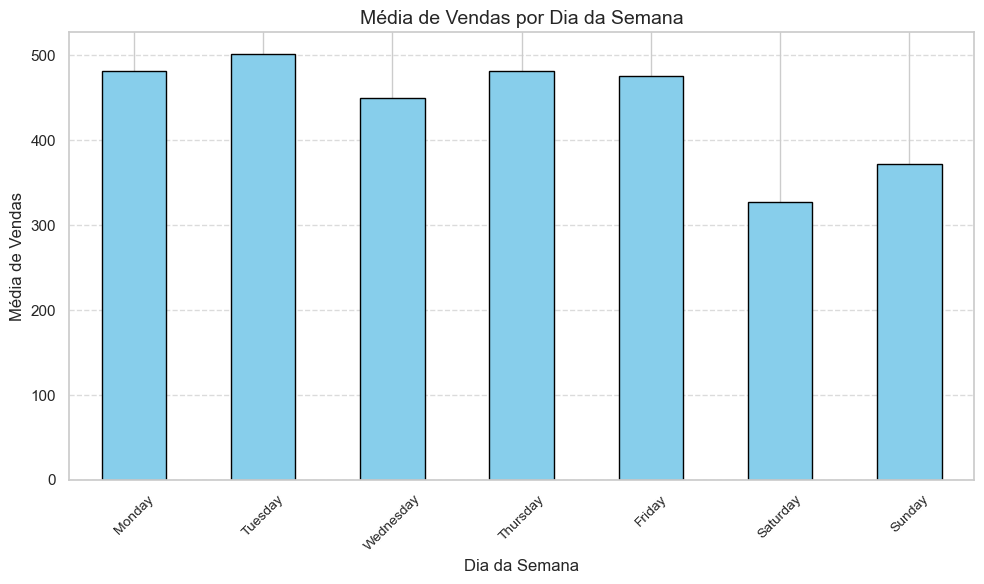

In [167]:
# Calcular a média de vendas por dia da semana
weekday_sales = total_shops.groupby('Weekday')['TotalValue'].mean() \
                    .sort_index(key=lambda x: pd.Categorical(x, 
                        categories=['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'], 
                        ordered=True))

# Criar o gráfico de barras
plt.figure(figsize=(10, 6))
weekday_sales.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Média de Vendas por Dia da Semana', fontsize=14)
plt.xlabel('Dia da Semana', fontsize=12)
plt.ylabel('Média de Vendas', fontsize=12)
plt.xticks(rotation=45, fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


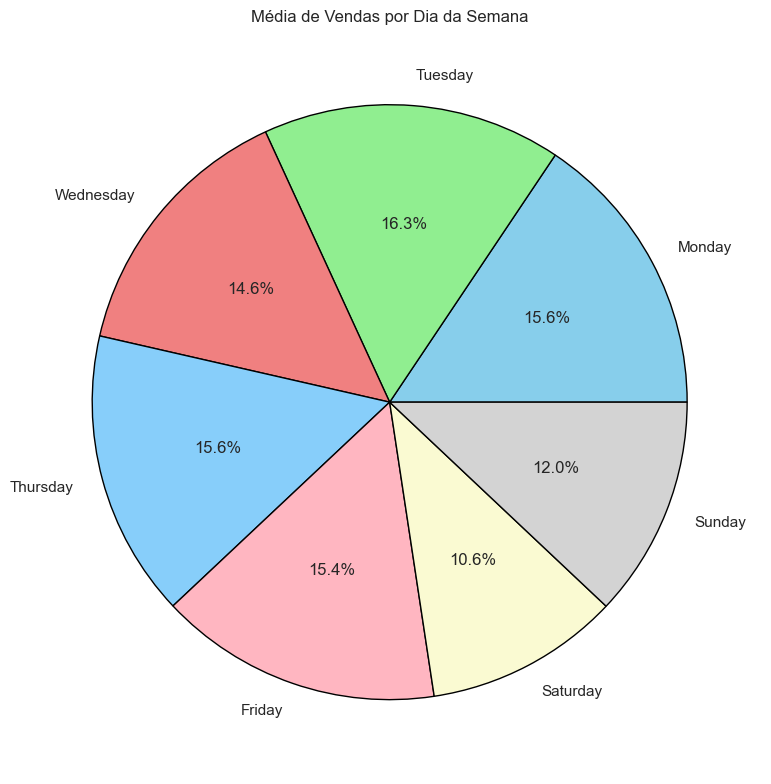

In [168]:

# Supondo que 'weekday_sales' já esteja calculado
plt.figure(figsize=(8, 8))

# Criando o gráfico circular (gráfico de pizza)
weekday_sales.plot(kind='pie', autopct='%1.1f%%', colors=['skyblue', 'lightgreen', 'lightcoral', 'lightskyblue', 'lightpink', 'lightgoldenrodyellow', 'lightgray'], 
                   wedgeprops={'edgecolor': 'black'}, legend=False)

# Adicionando título
plt.title('Média de Vendas por Dia da Semana')

# Exibindo o gráfico
plt.ylabel('')  # Remove o rótulo "Vendas" no gráfico
plt.tight_layout()
plt.show()

Variações Diárias nas Vendas:

O gráfico de linhas mostra uma grande variação no volume de vendas diárias ao longo do tempo. Há picos notáveis em alguns períodos específicos, sugerindo promoções, sazonalidade, ou eventos específicos que geraram maior volume de vendas. Embora haja flutuações significativas, a tendência parece relativamente consistente em termos de frequência de vendas.

Distribuição de Vendas por Dia da Semana:

O gráfico de barras mostra que os dias da semana com maior média de vendas são a segunda-feira e a terça-feira, seguidos de perto pela quarta e quinta feira.
Os dias do fim de semana (sábado e domingo) apresentam as menores médias de vendas, com o sábado sendo o menor, que indica um padrão onde o público realiza mais compras durante os dias úteis.

Com o gráfico circular a maior fatia está atribuída à terça-feira (16,3%), enquanto o sábado (10,6%) tem a menor participação no total das vendas.
Os dias úteis da semana (de segunda a sexta-feira) representam a maior parte do volume de vendas (cerca de 75%-80%), enquanto o fim de semana contribui com uma porcentagem menor.

Os dias úteis são os mais lucrativos, principalmente segunda-feira e terça-feira, o que pode refletir uma tendência em que consumidores fazem mais compras no início da semana. As vendas ao fim de semana são mais baixas, especialmente no sábado e domingo, possivelmente indicando mudanças nos hábitos de compra ou disponibilidade dos consumidores.
Alguns meses, como outubro e novembro, se destacam com picos de vendas significativos, sugerindo sazonalidade ou eventos promocionais como grandes influenciadores.


Relação entre Mês e Dia da Semana

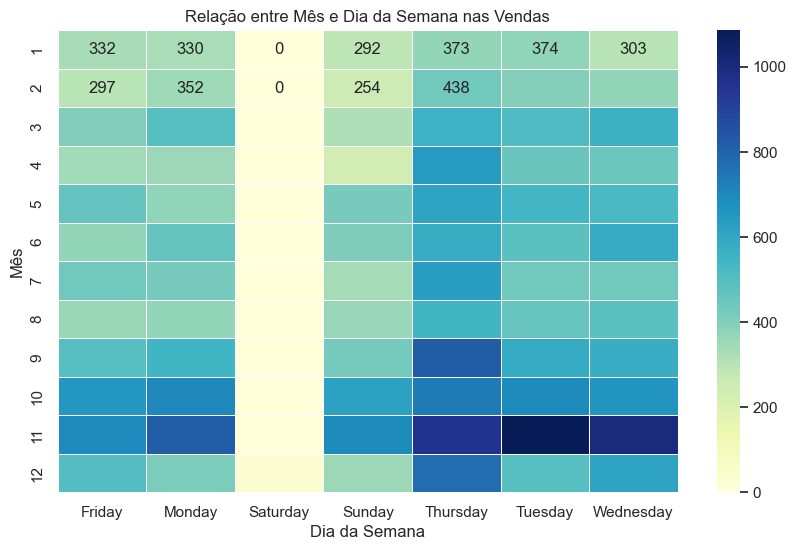

In [169]:
# Criar a tabela de contingência entre mês e dia da semana
month_weekday_crosstab = pd.crosstab(total_shops['Month'], total_shops['Weekday'])

# Criar o heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(month_weekday_crosstab, annot=True, cmap='YlGnBu', fmt='g', linewidths=.5)
plt.title('Relação entre Mês e Dia da Semana nas Vendas')
plt.xlabel('Dia da Semana')
plt.ylabel('Mês')
plt.show()


O gráfico mostra um heatmap da relação entre os meses do ano e os dias da semana em termos de vendas. 

Algumas células possuem valores significativamente mais altos, indicando picos de vendas em determinados meses e dias da semana.
Por exemplo, no mês 12 (Dezembro), há uma concentração maior de vendas nas terças e quartas-feiras, o que pode indicar aumento na demanda próximo ao fim do ano.

Em meses como janeiro (1) e fevereiro (2), há pouca ou nenhuma movimentação em termos de vendas registradas, sugerindo uma baixa sazonalidade ou ausência de dados nesses meses.
A atividade de vendas está concentrada em poucos dias e meses específicos. Por exemplo: Terças-feiras e quartas-feiras frequentemente apresentam números mais altos em meses  diferentes. Alguns meses, como março (3) e abril (4), apresentam mais equilíbrio nos dias da semana.

Os picos no mês 12 (Dezembro) sugerem sazonalidade, enquanto outros meses mostram padrões menos intensos, o que pode ser indicativo de de padrões de consumo dependentes da época do ano.

## Conclusão

Concluindo, com base na análise realizada pode-se afirmar que existem padrões de compra por parte dos consumidores neste conjunto de dados. A maioria das transações envolve compras de baixo valor e quantidades, refletindo um comportamento de consumidores individuais que preferem pequenas aquisições frequentes, há transações significativas em termos de valor e quantidade, mas estas são exceções, indicando a presença de compradores atacadistas.

Com base nos mercados geográficos o Reino Unido domina as vendas, representando 93,3% das transações, com um volume de vendas superior a 14 milhões. Essa dependência apresenta riscos e reforça a necessidade de se tentar implementar uma diversificação nos restantes mercados presentes. Países como a Alemanha, a França, o EIRE e os Países Baixos possuem potencial como mercados secundários, enquanto o Japão e Singapura mostram valores médios elevados, embora com alta dispersão, o que exigeriam uma maior análise. Mercados como o da Nigéria e da Arábia Saudita têm impacto insignificante, não justificando investimentos imediatos, mas a sua monitorização futura pode ser oportuna.

Os meses de novembro e dezembro registram picos de vendas devido a sazonalidade (Natal), enquanto janeiro e fevereiro tapresentam baixos desempenhos. Durante a semana, segunda e terça-feira são os dias com maiores volumes de vendas, enquanto sábados e domingos têm menor atividade. 

Em suma os mercados diversificados valorizam uma variedade maior de produtos, enquanto volumes altos concentram-se mais itens específicos e com base na análise histórica demonstra-se o crescimento no valor médio e na mediana das transações, indicando um aumento gradual na qualidade do consumo.

Algumas estratégias e recomendações que se podem vir a tomar são a diversificação de Mercados, ou seja, reduzir a dependência do Reino Unido através de investimentos em mercados secundários como a França e a Alemanha; maximizar as vendas durante novembro e dezembro e implementar campanhas promocionais nos meses de menor desempenho e investir em marketing localizado adaptaando estratégias a contextos culturais e econômicos específicos dos mercados secundários, tudo de modo a aumentar os números das vendas.

Todos os códigos aqui desenvolvidos foram com ajuda com ChatGPT e dos notebooks estudados nas aulas.